In [7]:
import sys
sys.path.insert(0, "../..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import yaml

# --- Setup ---
with open("../../config.yml", "r") as f:
    config = yaml.safe_load(f)

# --- Load indicators panel ---
panel = pd.read_parquet("../../data/processed_data/analysis_panel.parquet")

In [8]:
# --- Panel exploration ---
SELECTED_AREA = "South Yorkshire"  # will search for MCA or constituent LADs

print("=== SHAPE ===")
print(panel.shape)

print("\n=== COLUMNS ===")
for c in panel.columns:
    print(c)

print("\n=== DTYPES ===")
print(panel.dtypes)

print("\n=== SAMPLE ROWS (first 3) ===")
print(panel.head(3).to_string())

print("\n=== UNIQUE YEARS (if year column exists) ===")
year_cols = [c for c in panel.columns if "year" in c.lower()]
if year_cols:
    for yc in year_cols:
        print(f"{yc}: {sorted(panel[yc].unique())}")
else:
    print("No obvious year column found")

print("\n=== GEOGRAPHY COLUMNS ===")
geo_cols = [c for c in panel.columns if any(x in c.lower() for x in ["lad", "area", "region", "mca", "name", "code"])]
for gc in geo_cols:
    print(f"{gc}: {panel[gc].nunique()} unique values")
    print(f"  Sample: {panel[gc].unique()[:5]}")

print("\n=== LQ COLUMNS ===")
lq_cols = [c for c in panel.columns if "lq" in c.lower()]
print(lq_cols)

print("\n=== SOUTH YORKSHIRE ROWS ===")
# Try to find South Yorkshire in whichever geo column exists
for gc in geo_cols:
    sy_rows = panel[panel[gc].astype(str).str.contains("South Yorkshire|Sheffield|Rotherham|Barnsley|Doncaster", case=False, na=False)]
    if len(sy_rows) > 0:
        print(f"Found via column '{gc}':")
        print(sy_rows[geo_cols + lq_cols].to_string())
        break

=== SHAPE ===
(17150, 57)

=== COLUMNS ===
YEAR
GEOGRAPHY_CODE
GEOGRAPHY_NAME
IS8_SECTOR
EMPLOYEES
BUSINESSES
gva_per_hour
weekly_pay
employment_rate
unemployment_rate
gdhi_per_head
new_enterprises
deaths_of_enterprises
active_enterprises
high_growth_enterprises
public_transport_to_employer
drive_to_employer
cycle_to_employer
broadband_availability
4g_area_coverage
ks2_attainment
gcse_by_age_19
ofsted
persistent_absences
persistent_absences_fsm
persistent_absences_cla
early_years_comms
early_years_literacy
early_years_maths
fe_and_skills_achievements
apprenticeship_starts
apprenticeship_achievements
level_3+_qualifications
fe_and_skills_participation
female_hle
male_hle
smokers
reception_obesity
year_6_obesity
adult_obesity
cancer_diagnosis
under_75_mortality_rate
life_satisfaction
worthwhile
happiness
anxiety
net_additions
lq_bus
emp_share
lq_emp
growth_emp
cagr_emp
growth_bus
cagr_bus
related_variety
size_large_share
size_micro_share

=== DTYPES ===
YEAR                              

Within each LAD's structural peer group, the top 10% of performers by IS8 employment and business presence were identified as the achievable benchmark. The gap between each SY LAD and that benchmark on underlying conditions reveals the specific variables most likely to be constraining IS8 development — not as a general structural disadvantage relative to wealthier places, but as a specific gap relative to comparable areas that have achieved better outcomes.

In [9]:
# ============================================================
# CELL 1 — MCA-level IS8 footprint (Step 1)
# Recompute LQs by aggregating raw EMPLOYEES/BUSINESSES to MCA
# ============================================================

SY_CODES = ["E08000016", "E08000017", "E08000018", "E08000019"]
YEAR = 2022

df = panel[panel["YEAR"] == YEAR].copy()

# National totals per sector
nat = df.groupby("IS8_SECTOR")[["EMPLOYEES", "BUSINESSES"]].sum().rename(
    columns={"EMPLOYEES": "nat_emp", "BUSINESSES": "nat_bus"}
)
nat_total_emp = df["EMPLOYEES"].sum()
nat_total_bus = df["BUSINESSES"].sum()

# MCA totals per sector
sy = df[df["GEOGRAPHY_CODE"].isin(SY_CODES)].groupby("IS8_SECTOR")[["EMPLOYEES", "BUSINESSES"]].sum().rename(
    columns={"EMPLOYEES": "sy_emp", "BUSINESSES": "sy_bus"}
)
sy_total_emp = sy["sy_emp"].sum()
sy_total_bus = sy["sy_bus"].sum()

# Merge and compute LQs
footprint = sy.join(nat)
footprint["lq_emp_mca"] = (footprint["sy_emp"] / sy_total_emp) / (footprint["nat_emp"] / nat_total_emp)
footprint["lq_bus_mca"] = (footprint["sy_bus"] / sy_total_bus) / (footprint["nat_bus"] / nat_total_bus)
footprint["emp_bus_gap"] = footprint["lq_emp_mca"] - footprint["lq_bus_mca"]

footprint = footprint.sort_values("lq_emp_mca", ascending=False)

print("=== SOUTH YORKSHIRE MCA — IS8 FOOTPRINT (2022) ===")
print(f"{'Sector':<40} {'LQ emp':>8} {'LQ bus':>8} {'Gap (e-b)':>10}  Signal")
print("-" * 80)
for sector, row in footprint.iterrows():
    lq_e = row["lq_emp_mca"]
    lq_b = row["lq_bus_mca"]
    gap  = row["emp_bus_gap"]
    if lq_e > 1.25:
        signal = "ANCHOR"
    elif lq_e > 1.0:
        signal = "above avg"
    elif lq_e > 0.75:
        signal = "below avg"
    else:
        signal = "absent/weak"
    print(f"{sector:<40} {lq_e:>8.2f} {lq_b:>8.2f} {gap:>10.2f}  {signal}")

=== SOUTH YORKSHIRE MCA — IS8 FOOTPRINT (2022) ===
Sector                                     LQ emp   LQ bus  Gap (e-b)  Signal
--------------------------------------------------------------------------------
Life Sciences                                1.51     1.33       0.18  ANCHOR
Advanced Manufacturing                       1.16     1.69      -0.53  above avg
Professional and Business Services           1.09     1.01       0.08  above avg
Financial Services                           1.05     1.09      -0.04  above avg
Digital and Technologies                     0.85     1.01      -0.16  below avg
Creative Industries                          0.74     0.85      -0.12  absent/weak
Defence                                      0.00     0.00       0.00  absent/weak


In [10]:
# ============================================================
# CELL 2 — Trajectory analysis (Step 2)
# Use cagr_emp / cagr_bus already in panel (2016–2022 window)
# ============================================================

# Take most recent year per LAD×sector for CAGR (it covers full window)
traj = panel[
    (panel["GEOGRAPHY_CODE"].isin(SY_CODES)) & (panel["YEAR"] == YEAR)
].groupby("IS8_SECTOR")[["cagr_emp", "cagr_bus", "growth_emp", "growth_bus"]].mean()

# National median CAGR for comparison
nat_traj = panel[panel["YEAR"] == YEAR].groupby("IS8_SECTOR")[["cagr_emp", "cagr_bus"]].median().rename(
    columns={"cagr_emp": "nat_med_cagr_emp", "cagr_bus": "nat_med_cagr_bus"}
)

traj = traj.join(nat_traj)
traj["vs_nat_emp"] = traj["cagr_emp"] - traj["nat_med_cagr_emp"]
traj["vs_nat_bus"] = traj["cagr_bus"] - traj["nat_med_cagr_bus"]

print("\n=== TRAJECTORY (CAGR 2016–2022, SY MCA avg vs national median) ===")
print(f"{'Sector':<40} {'CAGR emp':>9} {'CAGR bus':>9} {'vs nat emp':>11} {'vs nat bus':>11}  Trajectory")
print("-" * 100)
for sector, row in traj.sort_values("cagr_emp", ascending=False).iterrows():
    ce = float(row["cagr_emp"]) if pd.notna(row["cagr_emp"]) else None
    cb = float(row["cagr_bus"]) if pd.notna(row["cagr_bus"]) else None
    ve = float(row["vs_nat_emp"]) if pd.notna(row["vs_nat_emp"]) else None
    vb = float(row["vs_nat_bus"]) if pd.notna(row["vs_nat_bus"]) else None

    if ce is None or ve is None:
        traj_label = "no data"
    elif ce > 0.03 and ve > 0:
        traj_label = "GROWING (above nat)"
    elif ce > 0 and ve < 0:
        traj_label = "growing (below nat)"
    elif ce < 0 and ve < 0:
        traj_label = "DECLINING"
    else:
        traj_label = "mixed"

    ce_s = f"{ce:>9.3f}" if ce is not None else f"{'NA':>9}"
    cb_s = f"{cb:>9.3f}" if cb is not None else f"{'NA':>9}"
    ve_s = f"{ve:>11.3f}" if ve is not None else f"{'NA':>11}"
    vb_s = f"{vb:>11.3f}" if vb is not None else f"{'NA':>11}"
    print(f"{sector:<40} {ce_s} {cb_s} {ve_s} {vb_s}  {traj_label}")


=== TRAJECTORY (CAGR 2016–2022, SY MCA avg vs national median) ===
Sector                                    CAGR emp  CAGR bus  vs nat emp  vs nat bus  Trajectory
----------------------------------------------------------------------------------------------------
Life Sciences                                0.126    -0.059       0.107      -0.059  GROWING (above nat)
Advanced Manufacturing                       0.039     0.016       0.047       0.016  GROWING (above nat)
Financial Services                           0.019     0.011       0.032       0.011  mixed
Creative Industries                          0.005     0.010      -0.008       0.011  growing (below nat)
Professional and Business Services           0.002    -0.012      -0.009      -0.007  growing (below nat)
Digital and Technologies                    -0.005    -0.004      -0.006       0.015  DECLINING
Defence                                         NA        NA          NA          NA  no data


In [11]:
# ============================================================
# CELL 3 — Correlate scorecard (Step 3)
#
# PURPOSE:
# The national regression tells us which local conditions are
# associated with IS8 sector presence across all LADs. This cell
# takes those same variables and asks: how does South Yorkshire
# score on each one, relative to the national median?
#
# This is the bridge between the national analysis (Phase 1) and
# the local area assessment. A variable where SY scores ABOVE the
# national median is a potential asset; BELOW is a potential gap
# or barrier.
#
# NOTE: CORRELATE_VARS below is currently a placeholder using
# theoretically sensible predictors. Once the regression is
# complete, replace this list with the variables that came out
# as statistically significant — ideally sector by sector if
# different variables matter for different IS8 sectors.
# ============================================================

CORRELATE_VARS = [
    "level_3+_qualifications",    # skills pipeline — key for knowledge-intensive sectors
    "apprenticeship_starts",      # technical skills supply
    "broadband_availability",     # digital infrastructure
    "4g_area_coverage",           # connectivity
    "drive_to_employer",          # labour market accessibility
    "public_transport_to_employer",
    "active_enterprises",         # enterprise base density
    "high_growth_enterprises",    # dynamism of local business base
    "new_enterprises",            # entrepreneurial churn
    "unemployment_rate",          # labour market slack (higher = more flexibility)
    "fe_and_skills_achievements", # workforce upskilling capacity
]

# --- Step 3a: Extract LAD-level values for 2022 ---
# Correlate variables are LAD-level (not sector-specific), so they repeat
# identically across all IS8_SECTOR rows for a given LAD and year.
# We drop duplicates to get one row per LAD before doing any aggregation.
lad_vars = (
    panel[panel["YEAR"] == YEAR]
    .drop_duplicates(subset="GEOGRAPHY_CODE")[["GEOGRAPHY_CODE", "GEOGRAPHY_NAME"] + CORRELATE_VARS]
    .set_index("GEOGRAPHY_CODE")
)

# --- Step 3b: Compute national median across all 350 LADs ---
# We use median rather than mean because many variables are right-skewed
# (e.g. enterprise counts are pulled up by large urban centres like London).
nat_medians = lad_vars[CORRELATE_VARS].median()

# --- Step 3c: Average the 4 SY LADs into one MCA-level figure ---
# Simple unweighted mean across Barnsley, Doncaster, Rotherham, Sheffield.
# This treats each LAD equally — a population-weighted version would be
# more precise but requires an extra population lookup.
sy_means = lad_vars.loc[SY_CODES, CORRELATE_VARS].mean()

# --- Step 3d: Build the scorecard ---
# % diff = how far SY sits above or below the national median.
# Threshold of ±5% for ABOVE/BELOW is a practical judgement call —
# tighten or loosen depending on how much variation exists in each variable.
scorecard = pd.DataFrame({
    "SY_mean":    sy_means,
    "nat_median": nat_medians,
})
scorecard["pct_diff"] = (scorecard["SY_mean"] - scorecard["nat_median"]) / scorecard["nat_median"] * 100
scorecard["position"] = scorecard["pct_diff"].apply(
    lambda x: "ABOVE ▲" if x > 5 else ("BELOW ▼" if x < -5 else "~PARITY")
)

print("\n=== CORRELATE SCORECARD — SY MCA vs NATIONAL MEDIAN (2022) ===")
print("(Placeholder variables — replace with regression-significant predictors once available)\n")
print(f"{'Variable':<35} {'SY mean':>10} {'Nat median':>12} {'% diff':>8}  Position")
print("-" * 85)
for var, row in scorecard.iterrows():
    print(f"{var:<35} {row['SY_mean']:>10.2f} {row['nat_median']:>12.2f} {row['pct_diff']:>8.1f}%  {row['position']}")


=== CORRELATE SCORECARD — SY MCA vs NATIONAL MEDIAN (2022) ===
(Placeholder variables — replace with regression-significant predictors once available)

Variable                               SY mean   Nat median   % diff  Position
-------------------------------------------------------------------------------------
level_3+_qualifications                  55.08        60.40     -8.8%  BELOW ▼
apprenticeship_starts                  1014.25       945.50      7.3%  ABOVE ▲
broadband_availability                   77.00        77.15     -0.2%  ~PARITY
4g_area_coverage                         98.59        99.99     -1.4%  ~PARITY
drive_to_employer                         7.78         7.56      2.8%  ~PARITY
public_transport_to_employer             11.88        11.18      6.2%  ABOVE ▲
active_enterprises                    11626.25      5880.00     97.7%  ABOVE ▲
high_growth_enterprises                  40.00        25.00     60.0%  ABOVE ▲
new_enterprises                        1636.25    

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# CELL 4a — Prepare clustering dataset
#
# We cluster on rates/proportions only to avoid the size-bias
# problem where larger LADs (Sheffield) dominate on raw counts.
# All variables below are bounded or expressed as shares/rates.
# ============================================================

CLUSTER_VARS = [
    "unemployment_rate",          # labour market slack
    "level_3+_qualifications",    # higher skills share
    "gcse_by_age_19",             # secondary education attainment rate
    "apprenticeship_achievements",# technical skills pipeline (rate per provision)
    "broadband_availability",     # digital infrastructure coverage %
    "4g_area_coverage",           # mobile connectivity coverage %
    "drive_to_employer",          # % of jobs accessible by car
    "public_transport_to_employer",# % of jobs accessible by PT
    "cycle_to_employer",          # % of jobs accessible by cycle
    "size_large_share",           # share of large firms in local business base
    "size_micro_share",           # share of micro firms
    "ofsted",                     # education quality rate
    "persistent_absences",        # school engagement rate (inverse)
]

FOCUS_SECTORS = ["Life Sciences", "Advanced Manufacturing", "Digital and Technologies"]
YEAR = 2022

# Extract one row per LAD (cluster vars are sector-invariant)
lad_df = (
    panel[panel["YEAR"] == YEAR]
    .drop_duplicates(subset="GEOGRAPHY_CODE")
    .set_index("GEOGRAPHY_CODE")
    [["GEOGRAPHY_NAME"] + CLUSTER_VARS]
    .copy()
)

# Drop LADs with any missing values in cluster vars
before = len(lad_df)
lad_df = lad_df.dropna(subset=CLUSTER_VARS)
after = len(lad_df)
print(f"LADs retained after dropping missing: {after}/{before}")

# Standardise — essential for KMeans so no variable dominates by scale
scaler = StandardScaler()
X = scaler.fit_transform(lad_df[CLUSTER_VARS])

print(f"\nClustering on {len(CLUSTER_VARS)} variables across {after} LADs")
print("Variables:", CLUSTER_VARS)

LADs retained after dropping missing: 112/350

Clustering on 13 variables across 112 LADs
Variables: ['unemployment_rate', 'level_3+_qualifications', 'gcse_by_age_19', 'apprenticeship_achievements', 'broadband_availability', '4g_area_coverage', 'drive_to_employer', 'public_transport_to_employer', 'cycle_to_employer', 'size_large_share', 'size_micro_share', 'ofsted', 'persistent_absences']


In [13]:
# ============================================================
# CELL 4a (diagnostic) — Why are so many LADs being dropped?
#
# dropna removes a LAD if ANY variable is missing. One sparsely
# covered variable can silently eliminate hundreds of LADs.
# This cell finds the culprits so we can make an informed
# decision about which variables to keep.
# ============================================================

lad_df_full = (
    panel[panel["YEAR"] == YEAR]
    .drop_duplicates(subset="GEOGRAPHY_CODE")
    .set_index("GEOGRAPHY_CODE")
    [["GEOGRAPHY_NAME"] + CLUSTER_VARS]
    .copy()
)

print("=== MISSING VALUES PER VARIABLE ===")
print(f"{'Variable':<35} {'Missing':>8} {'% missing':>10}  {'Coverage':>10}")
print("-" * 70)
for var in CLUSTER_VARS:
    n_miss = lad_df_full[var].isna().sum()
    pct    = n_miss / len(lad_df_full) * 100
    bar    = "█" * int((100 - pct) / 5)
    print(f"{var:<35} {n_miss:>8} {pct:>9.1f}%  {bar}")

print(f"\nTotal LADs: {len(lad_df_full)}")
print(f"Complete cases (no missing on any var): {lad_df_full.dropna(subset=CLUSTER_VARS).shape[0]}")

# Show how many LADs are retained if we drop each variable one at a time
print("\n=== IMPACT OF REMOVING EACH VARIABLE ===")
print("(How many LADs would be retained if this variable were excluded?)")
print(f"{'Variable dropped':<35} {'LADs retained':>15}")
print("-" * 55)
for var in CLUSTER_VARS:
    remaining_vars = [v for v in CLUSTER_VARS if v != var]
    retained = lad_df_full.dropna(subset=remaining_vars).shape[0]
    print(f"{var:<35} {retained:>15}")

# Also check SY LADs specifically
print("\n=== MISSING VALUES FOR SY LADs SPECIFICALLY ===")
sy_full = lad_df_full.loc[[c for c in SY_CODES if c in lad_df_full.index]]
print(sy_full[CLUSTER_VARS].isnull().sum().to_string())

=== MISSING VALUES PER VARIABLE ===
Variable                             Missing  % missing    Coverage
----------------------------------------------------------------------
unemployment_rate                         21       6.0%  ██████████████████
level_3+_qualifications                    6       1.7%  ███████████████████
gcse_by_age_19                            59      16.9%  ████████████████
apprenticeship_achievements               55      15.7%  ████████████████
broadband_availability                     4       1.1%  ███████████████████
4g_area_coverage                           4       1.1%  ███████████████████
drive_to_employer                         71      20.3%  ███████████████
public_transport_to_employer              71      20.3%  ███████████████
cycle_to_employer                         71      20.3%  ███████████████
size_large_share                           1       0.3%  ███████████████████
size_micro_share                           1       0.3%  █████████████████

In [14]:
# ============================================================
# CELL 4a (fix) — test variable combinations for coverage
#
# The single-variable removal table was misleading because
# missing patterns overlap. Here we test dropping combinations
# of low-coverage variables to find the best tradeoff between
# variable richness and LAD coverage.
# ============================================================

# Variables with high missingness — candidates for removal
HIGH_MISSING = ["ofsted", "persistent_absences"]
MED_MISSING  = ["drive_to_employer", "public_transport_to_employer", "cycle_to_employer",
                 "gcse_by_age_19", "apprenticeship_achievements"]

print("=== COVERAGE UNDER DIFFERENT VARIABLE SETS ===\n")

test_sets = {
    "All 13 vars (baseline)":
        CLUSTER_VARS,
    "Drop ofsted + persistent_absences":
        [v for v in CLUSTER_VARS if v not in HIGH_MISSING],
    "Drop ofsted + persistent_absences + transport (3 vars)":
        [v for v in CLUSTER_VARS if v not in HIGH_MISSING + ["drive_to_employer", "public_transport_to_employer", "cycle_to_employer"]],
    "Drop ofsted + persistent_absences + gcse + apprenticeship":
        [v for v in CLUSTER_VARS if v not in HIGH_MISSING + ["gcse_by_age_19", "apprenticeship_achievements"]],
    "Drop all high+med missing (minimal set)":
        [v for v in CLUSTER_VARS if v not in HIGH_MISSING + MED_MISSING],
}

for label, var_set in test_sets.items():
    retained = lad_df_full.dropna(subset=var_set).shape[0]
    sy_retained = lad_df_full.loc[
        [c for c in SY_CODES if c in lad_df_full.index]
    ].dropna(subset=var_set).shape[0]
    print(f"{label}")
    print(f"  Variables: {len(var_set)}  |  LADs retained: {retained}/350  |  SY LADs: {sy_retained}/4")
    print(f"  Vars: {var_set}\n")

=== COVERAGE UNDER DIFFERENT VARIABLE SETS ===

All 13 vars (baseline)
  Variables: 13  |  LADs retained: 112/350  |  SY LADs: 4/4
  Vars: ['unemployment_rate', 'level_3+_qualifications', 'gcse_by_age_19', 'apprenticeship_achievements', 'broadband_availability', '4g_area_coverage', 'drive_to_employer', 'public_transport_to_employer', 'cycle_to_employer', 'size_large_share', 'size_micro_share', 'ofsted', 'persistent_absences']

Drop ofsted + persistent_absences
  Variables: 11  |  LADs retained: 270/350  |  SY LADs: 4/4
  Vars: ['unemployment_rate', 'level_3+_qualifications', 'gcse_by_age_19', 'apprenticeship_achievements', 'broadband_availability', '4g_area_coverage', 'drive_to_employer', 'public_transport_to_employer', 'cycle_to_employer', 'size_large_share', 'size_micro_share']

Drop ofsted + persistent_absences + transport (3 vars)
  Variables: 8  |  LADs retained: 275/350  |  SY LADs: 4/4
  Vars: ['unemployment_rate', 'level_3+_qualifications', 'gcse_by_age_19', 'apprenticeship_ach

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# CELL 4a — Prepare clustering dataset
#
# We cluster on rates/proportions only to avoid the size-bias
# problem where larger LADs (Sheffield) dominate on raw counts.
# All variables below are bounded or expressed as shares/rates.
# ============================================================

CLUSTER_VARS = [
    "unemployment_rate",          # labour market slack
    "level_3+_qualifications",    # higher skills share
    "gcse_by_age_19",             # secondary education attainment rate
    "apprenticeship_achievements",# technical skills pipeline (rate per provision)
    "broadband_availability",     # digital infrastructure coverage %
    "4g_area_coverage",           # mobile connectivity coverage %
    "drive_to_employer",          # % of jobs accessible by car
    "public_transport_to_employer",# % of jobs accessible by PT
    "cycle_to_employer",          # % of jobs accessible by cycle
    "size_large_share",           # share of large firms in local business base
    "size_micro_share",           # share of micro firms
    # ofsted and persistent_absences dropped — 63% missing each, and both
    # are school-level measures with a 15-20 year lag to the workforce.
    # Dropping them recovers 270/350 LADs vs 112 with no meaningful
    # loss to the EEG-based analytical framework.
]

FOCUS_SECTORS = ["Life Sciences", "Advanced Manufacturing", "Digital and Technologies"]
YEAR = 2022

# Extract one row per LAD (cluster vars are sector-invariant)
lad_df = (
    panel[panel["YEAR"] == YEAR]
    .drop_duplicates(subset="GEOGRAPHY_CODE")
    .set_index("GEOGRAPHY_CODE")
    [["GEOGRAPHY_NAME"] + CLUSTER_VARS]
    .copy()
)

# Drop LADs with any missing values in cluster vars
before = len(lad_df)
lad_df = lad_df.dropna(subset=CLUSTER_VARS)
after = len(lad_df)
print(f"LADs retained after dropping missing: {after}/{before}")

# Standardise — essential for KMeans so no variable dominates by scale
scaler = StandardScaler()
X = scaler.fit_transform(lad_df[CLUSTER_VARS])

print(f"\nClustering on {len(CLUSTER_VARS)} variables across {after} LADs")
print("Variables:", CLUSTER_VARS)

LADs retained after dropping missing: 270/350

Clustering on 11 variables across 270 LADs
Variables: ['unemployment_rate', 'level_3+_qualifications', 'gcse_by_age_19', 'apprenticeship_achievements', 'broadband_availability', '4g_area_coverage', 'drive_to_employer', 'public_transport_to_employer', 'cycle_to_employer', 'size_large_share', 'size_micro_share']


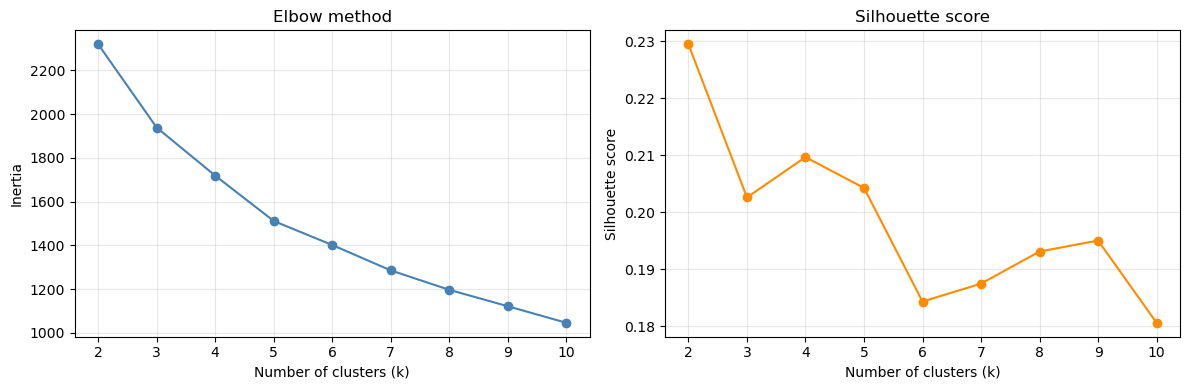


Silhouette scores by k:
  k=2: 0.2295
  k=3: 0.2026
  k=4: 0.2097
  k=5: 0.2043
  k=6: 0.1844
  k=7: 0.1875
  k=8: 0.1931
  k=9: 0.1951
  k=10: 0.1806


In [16]:
# ============================================================
# CELL 4b — Choose number of clusters (elbow + silhouette)
#
# We test k=2..10. Elbow looks for where inertia stops falling
# sharply. Silhouette measures how well-separated clusters are
# (higher = better, max=1). Pick k where both agree.
# ============================================================

k_range = range(2, 11)
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(list(k_range), inertias, "o-", color="steelblue")
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow method")
ax1.grid(alpha=0.3)

ax2.plot(list(k_range), silhouettes, "o-", color="darkorange")
ax2.set_xlabel("Number of clusters (k)")
ax2.set_ylabel("Silhouette score")
ax2.set_title("Silhouette score")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("cluster_selection.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSilhouette scores by k:")
for k, s in zip(k_range, silhouettes):
    print(f"  k={k}: {s:.4f}")

In [17]:
# ============================================================
# CELL 4c — Fit final model and find SY comparators
#
# Set K below based on the elbow/silhouette output from 4b.
# Then for each SY LAD and each focus sector, we find other
# LADs in the same cluster with higher IS8 LQ — these are the
# "similar conditions, better outcomes" comparators.
# ============================================================

K = 4  # <-- adjust after inspecting 4b output

km_final = KMeans(n_clusters=K, random_state=42, n_init=10)
lad_df["cluster"] = km_final.fit_predict(X)

# Attach LQ values (one per LAD×sector) for the focus sectors
lq_lookup = (
    panel[
        (panel["YEAR"] == YEAR) &
        (panel["IS8_SECTOR"].isin(FOCUS_SECTORS))
    ]
    .set_index(["GEOGRAPHY_CODE", "IS8_SECTOR"])
    [["lq_emp", "lq_bus"]]
)

print(f"\n=== CLUSTER MEMBERSHIPS — SY LADs (k={K}) ===")
for code in SY_CODES:
    if code in lad_df.index:
        name    = lad_df.loc[code, "GEOGRAPHY_NAME"]
        cluster = lad_df.loc[code, "cluster"]
        print(f"  {name} ({code}): Cluster {cluster}")

print(f"\n=== COMPARATOR LADs — same cluster, higher LQ emp (top 5 per sector) ===")
for code in SY_CODES:
    if code not in lad_df.index:
        continue
    name    = lad_df.loc[code, "GEOGRAPHY_NAME"]
    cluster = lad_df.loc[code, "cluster"]
    cluster_lads = lad_df[lad_df["cluster"] == cluster].index.tolist()

    print(f"\n--- {name} (Cluster {cluster}, n={len(cluster_lads)} LADs) ---")

    for sector in FOCUS_SECTORS:
        # Get LQ for all LADs in same cluster
        cluster_lqs = (
            lq_lookup.xs(sector, level="IS8_SECTOR")
            .reindex(cluster_lads)
            .dropna()
            .sort_values("lq_emp", ascending=False)
        )
        # SY LAD's own LQ
        sy_lq = lq_lookup.xs(sector, level="IS8_SECTOR").loc[code, "lq_emp"] if code in lq_lookup.xs(sector, level="IS8_SECTOR").index else None

        # Top 5 comparators with higher LQ (excluding the SY LAD itself)
        comparators = cluster_lqs[
            (cluster_lqs.index != code) &
            (cluster_lqs["lq_emp"] > (sy_lq if sy_lq else 0))
        ].head(5)

        print(f"\n  [{sector}] — {name} lq_emp: {sy_lq:.2f}" if sy_lq else f"\n  [{sector}] — {name} lq_emp: N/A")
        if len(comparators) == 0:
            print("    No comparators with higher LQ in same cluster")
        else:
            print(f"  {'LAD':<30} {'lq_emp':>8} {'lq_bus':>8}")
            for comp_code, comp_row in comparators.iterrows():
                comp_name = lad_df.loc[comp_code, "GEOGRAPHY_NAME"] if comp_code in lad_df.index else comp_code
                print(f"  {comp_name:<30} {comp_row['lq_emp']:>8.2f} {comp_row['lq_bus']:>8.2f}")


=== CLUSTER MEMBERSHIPS — SY LADs (k=4) ===
  Barnsley (E08000016): Cluster 0
  Doncaster (E08000017): Cluster 0
  Rotherham (E08000018): Cluster 0
  Sheffield (E08000019): Cluster 0

=== COMPARATOR LADs — same cluster, higher LQ emp (top 5 per sector) ===

--- Barnsley (Cluster 0, n=121 LADs) ---

  [Life Sciences] — Barnsley lq_emp: 0.42
  LAD                              lq_emp   lq_bus
  Broxtowe                           7.66     0.00
  Vale of White Horse                7.42     3.95
  Halton                             5.78     2.26
  Swindon                            4.83     0.38
  Crawley                            4.35     0.72

  [Advanced Manufacturing] — Barnsley lq_emp: 0.77
  LAD                              lq_emp   lq_bus
  Tewkesbury                         7.20     1.92
  Derby                              5.70     1.11
  South Gloucestershire              4.44     1.22
  Sunderland                         4.30     1.40
  Plymouth                           3.94   

LADs retained after dropping missing: 270/350

Clustering on 11 variables across 270 LADs
Variables: ['unemployment_rate', 'level_3+_qualifications', 'gcse_by_age_19', 'apprenticeship_achievements', 'broadband_availability', '4g_area_coverage', 'drive_to_employer', 'public_transport_to_employer', 'cycle_to_employer', 'size_large_share', 'size_micro_share']


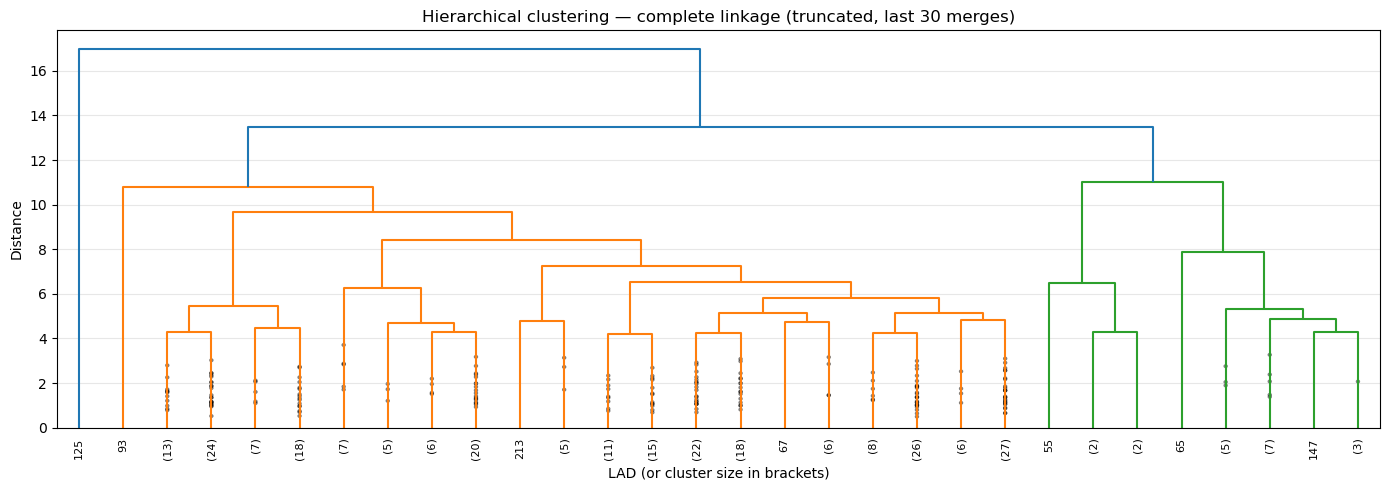

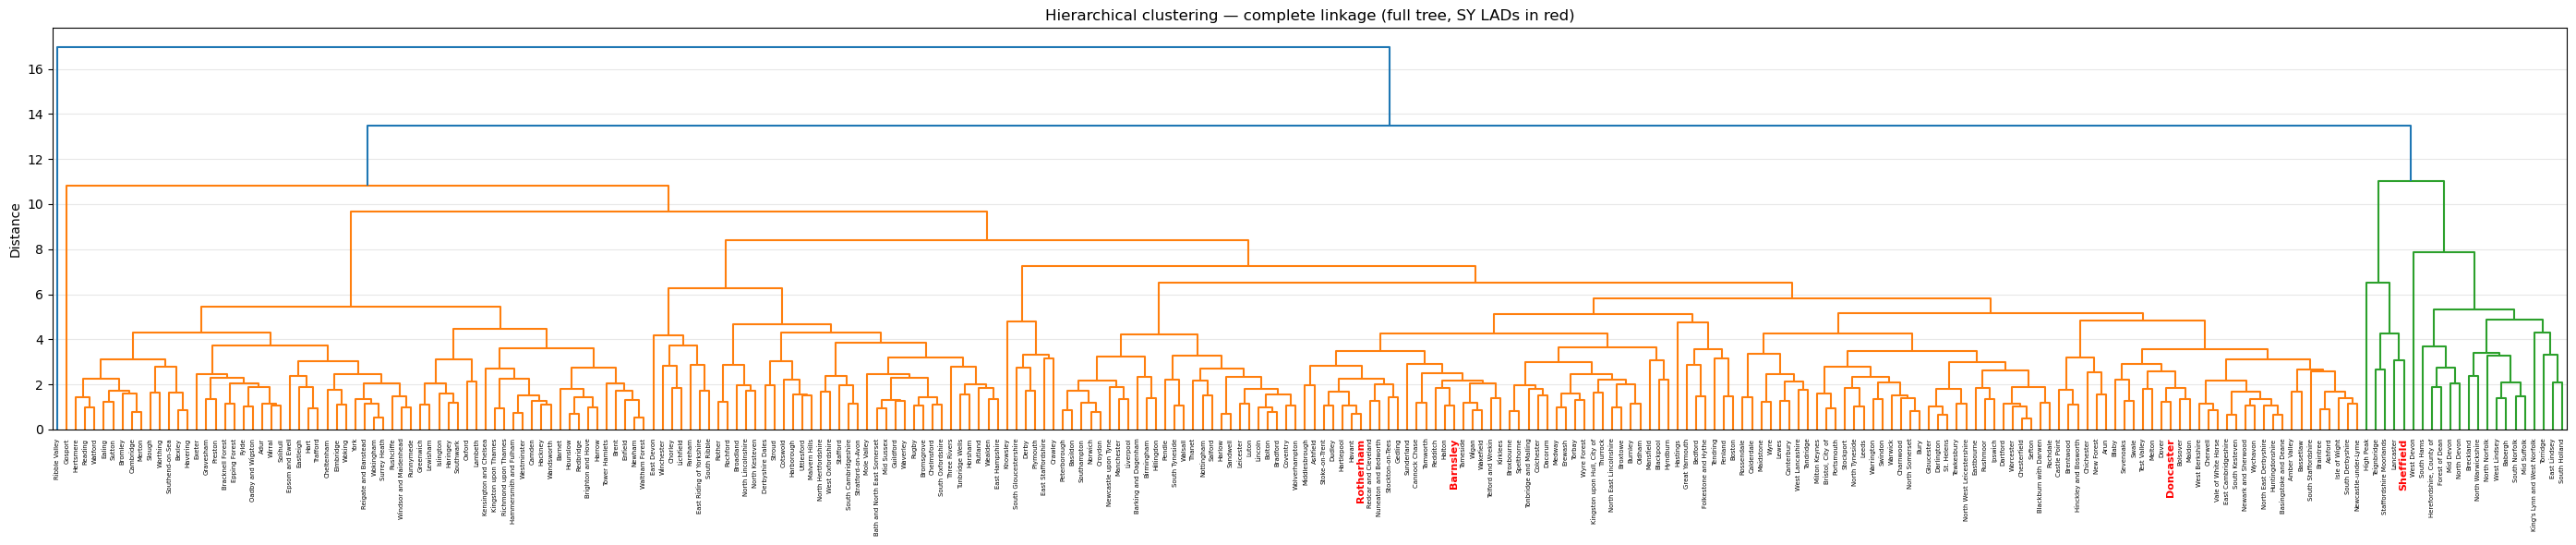

SY LADs positions in leaf order:
  Barnsley: leaf position 150/270
  Doncaster: leaf position 227/270
  Rotherham: leaf position 140/270
  Sheffield: leaf position 252/270
=== TREE CUT AT t=5.5 ===
Number of clusters formed: 13

Cluster sizes (top 15 largest):
  Cluster 7: 67 LADs
  Cluster 1: 62 LADs
  Cluster 6: 47 LADs
  Cluster 3: 31 LADs
  Cluster 5: 26 LADs
  Cluster 11: 16 LADs
  Cluster 2: 7 LADs
  Cluster 4: 6 LADs
  Cluster 9: 4 LADs
  Cluster 10: 1 LADs
  Cluster 12: 1 LADs
  Cluster 8: 1 LADs
  Cluster 13: 1 LADs

=== CLUSTER MEMBERSHIPS — SY LADs ===
  Barnsley (E08000016): Cluster 6  (n=47 LADs)
  Doncaster (E08000017): Cluster 7  (n=67 LADs)
  Rotherham (E08000018): Cluster 6  (n=47 LADs)
  Sheffield (E08000019): Cluster 9  (n=4 LADs)

=== COMPARATOR LADs — same cluster, higher LQ emp (top 5 per sector) ===

--- Barnsley (Cluster 6, n=47 LADs) ---
    All LADs in cluster: ['Hartlepool', 'Middlesbrough', 'Redcar and Cleveland', 'Stockton-on-Tees', 'Halton', 'Blackpool', '

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# CELL 4a — Prepare clustering dataset
#
# We cluster on rates/proportions only to avoid the size-bias
# problem where larger LADs (Sheffield) dominate on raw counts.
# All variables below are bounded or expressed as shares/rates.
# ============================================================

CLUSTER_VARS = [
    "unemployment_rate",          # labour market slack
    "level_3+_qualifications",    # higher skills share
    "gcse_by_age_19",             # secondary education attainment rate
    "apprenticeship_achievements",# technical skills pipeline (rate per provision)
    "broadband_availability",     # digital infrastructure coverage %
    "4g_area_coverage",           # mobile connectivity coverage %
    "drive_to_employer",          # % of jobs accessible by car
    "public_transport_to_employer",# % of jobs accessible by PT
    "cycle_to_employer",          # % of jobs accessible by cycle
    "size_large_share",           # share of large firms in local business base
    "size_micro_share",           # share of micro firms
    # ofsted and persistent_absences dropped — 63% missing each, and both
    # are school-level measures with a 15-20 year lag to the workforce.
    # Dropping them recovers 270/350 LADs vs 112 with no meaningful
    # loss to the EEG-based analytical framework.
]

FOCUS_SECTORS = ["Life Sciences", "Advanced Manufacturing", "Digital and Technologies"]
YEAR = 2022

# Extract one row per LAD (cluster vars are sector-invariant)
lad_df = (
    panel[panel["YEAR"] == YEAR]
    .drop_duplicates(subset="GEOGRAPHY_CODE")
    .set_index("GEOGRAPHY_CODE")
    [["GEOGRAPHY_NAME"] + CLUSTER_VARS]
    .copy()
)

# Drop LADs with any missing values in cluster vars
before = len(lad_df)
lad_df = lad_df.dropna(subset=CLUSTER_VARS)
after = len(lad_df)
print(f"LADs retained after dropping missing: {after}/{before}")

# Standardise — essential for KMeans so no variable dominates by scale
scaler = StandardScaler()
X = scaler.fit_transform(lad_df[CLUSTER_VARS])

print(f"\nClustering on {len(CLUSTER_VARS)} variables across {after} LADs")
print("Variables:", CLUSTER_VARS)


# ============================================================
# CELL 4b — Hierarchical clustering + dendrogram
#
# Complete linkage: clusters are merged based on the maximum
# distance between any two points across clusters. This produces
# tighter, more compact clusters than Ward or Average — better
# for finding genuinely similar comparators rather than just
# broadly similar groups.
#
# We show two views:
#   (1) Truncated dendrogram — last 30 merges, readable structure
#   (2) Full dendrogram — all 270 LADs, SY LADs highlighted in red
# ============================================================

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

# Build linkage matrix — this encodes the full tree
Z = linkage(X, method="complete", metric="euclidean")

# --- Helper: colour SY LADs red in full dendrogram ---
lad_names  = lad_df.index.tolist()          # ordered list of LAD codes after dropna
lad_labels = lad_df["GEOGRAPHY_NAME"].tolist()
sy_indices = [lad_names.index(c) for c in SY_CODES if c in lad_names]
sy_label_names = [lad_df.loc[c, "GEOGRAPHY_NAME"] for c in SY_CODES if c in lad_names]

def leaf_colour(leaf_id):
    return "red" if leaf_id in sy_indices else "black"

# ── Plot 1: Truncated dendrogram (last 30 merges) ──────────────────
fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(
    Z,
    ax=ax,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=8,
    show_contracted=True,
    color_threshold=0.7 * max(Z[:, 2]),
)
ax.set_title("Hierarchical clustering — complete linkage (truncated, last 30 merges)")
ax.set_xlabel("LAD (or cluster size in brackets)")
ax.set_ylabel("Distance")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("dendrogram_truncated.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 2: Full dendrogram with SY LADs highlighted ──────────────
fig, ax = plt.subplots(figsize=(28, 6))
ddata = dendrogram(
    Z,
    ax=ax,
    labels=lad_labels,
    leaf_rotation=90,
    leaf_font_size=5,
    color_threshold=0.7 * max(Z[:, 2]),
    no_plot=False,
)
# Colour SY LAD labels red
for lbl in ax.get_xticklabels():
    if lbl.get_text() in sy_label_names:
        lbl.set_color("red")
        lbl.set_fontsize(8)
        lbl.set_fontweight("bold")
ax.set_title("Hierarchical clustering — complete linkage (full tree, SY LADs in red)")
ax.set_ylabel("Distance")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("dendrogram_full.png", dpi=150, bbox_inches="tight")
plt.show()

print("SY LADs positions in leaf order:")
leaf_order = ddata["leaves"]
for idx in sy_indices:
    pos = leaf_order.index(idx)
    print(f"  {lad_df.iloc[idx]['GEOGRAPHY_NAME']}: leaf position {pos}/270")


# ============================================================
# CELL 4c — Cut the tree and find comparators
#
# Instead of fixing K upfront, we cut the dendrogram at a
# distance threshold t. Every LAD whose branch connects to
# an SY LAD below that threshold is a comparator candidate.
#
# T_CUT controls granularity:
#   - Higher t → larger, looser clusters (more comparators)
#   - Lower t  → smaller, tighter clusters (fewer, closer comparators)
#
# Start with t = 3.5 and adjust based on cluster sizes printed below.
# A good cut gives SY clusters of ~10-30 LADs.
# ============================================================

T_CUT = 5.5  # <-- adjust after inspecting dendrogram

labels_hier = fcluster(Z, t=T_CUT, criterion="distance")
lad_df["cluster"] = labels_hier

print(f"=== TREE CUT AT t={T_CUT} ===")
print(f"Number of clusters formed: {labels_hier.max()}")
print(f"\nCluster sizes (top 15 largest):")
sizes = pd.Series(labels_hier).value_counts().head(15)
for cid, cnt in sizes.items():
    print(f"  Cluster {cid}: {cnt} LADs")

print(f"\n=== CLUSTER MEMBERSHIPS — SY LADs ===")
for code in SY_CODES:
    if code in lad_df.index:
        name    = lad_df.loc[code, "GEOGRAPHY_NAME"]
        cluster = lad_df.loc[code, "cluster"]
        size    = (labels_hier == cluster).sum()
        print(f"  {name} ({code}): Cluster {cluster}  (n={size} LADs)")

print(f"\n=== COMPARATOR LADs — same cluster, higher LQ emp (top 5 per sector) ===")
for code in SY_CODES:
    if code not in lad_df.index:
        continue
    name    = lad_df.loc[code, "GEOGRAPHY_NAME"]
    cluster = lad_df.loc[code, "cluster"]
    cluster_lads = lad_df[lad_df["cluster"] == cluster].index.tolist()

    print(f"\n--- {name} (Cluster {cluster}, n={len(cluster_lads)} LADs) ---")
    print(f"    All LADs in cluster: {[lad_df.loc[c, 'GEOGRAPHY_NAME'] for c in cluster_lads]}")

    for sector in FOCUS_SECTORS:
        lq_sec = lq_lookup.xs(sector, level="IS8_SECTOR")
        sy_lq  = lq_sec.loc[code, "lq_emp"] if code in lq_sec.index else None

        cluster_lqs = (
            lq_sec.reindex(cluster_lads)
            .dropna()
            .sort_values("lq_emp", ascending=False)
        )
        comparators = cluster_lqs[
            (cluster_lqs.index != code) &
            (cluster_lqs["lq_emp"] > (sy_lq if sy_lq else 0))
        ].head(5)

        print(f"\n  [{sector}] — {name} lq_emp: {sy_lq:.2f}" if sy_lq else f"\n  [{sector}] — N/A")
        if len(comparators) == 0:
            print("    No comparators with higher LQ in same cluster")
        else:
            print(f"  {'LAD':<30} {'lq_emp':>8} {'lq_bus':>8}")
            for comp_code, comp_row in comparators.iterrows():
                comp_name = lad_df.loc[comp_code, "GEOGRAPHY_NAME"] if comp_code in lad_df.index else comp_code
                print(f"  {comp_name:<30} {comp_row['lq_emp']:>8.2f} {comp_row['lq_bus']:>8.2f}")

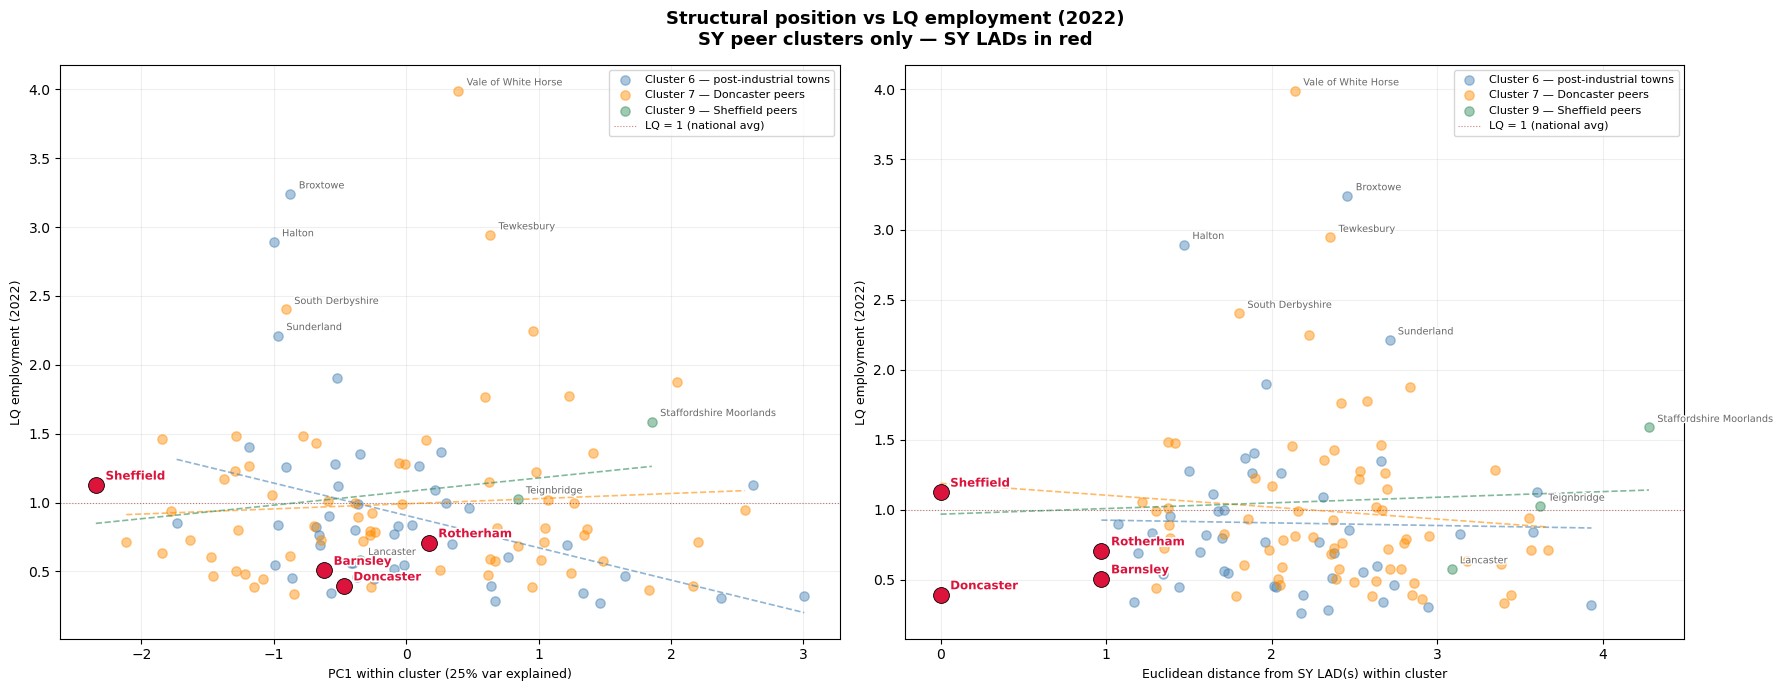

Saved: ../../output/graphs/franco/scatter_structural_lq_emp.png


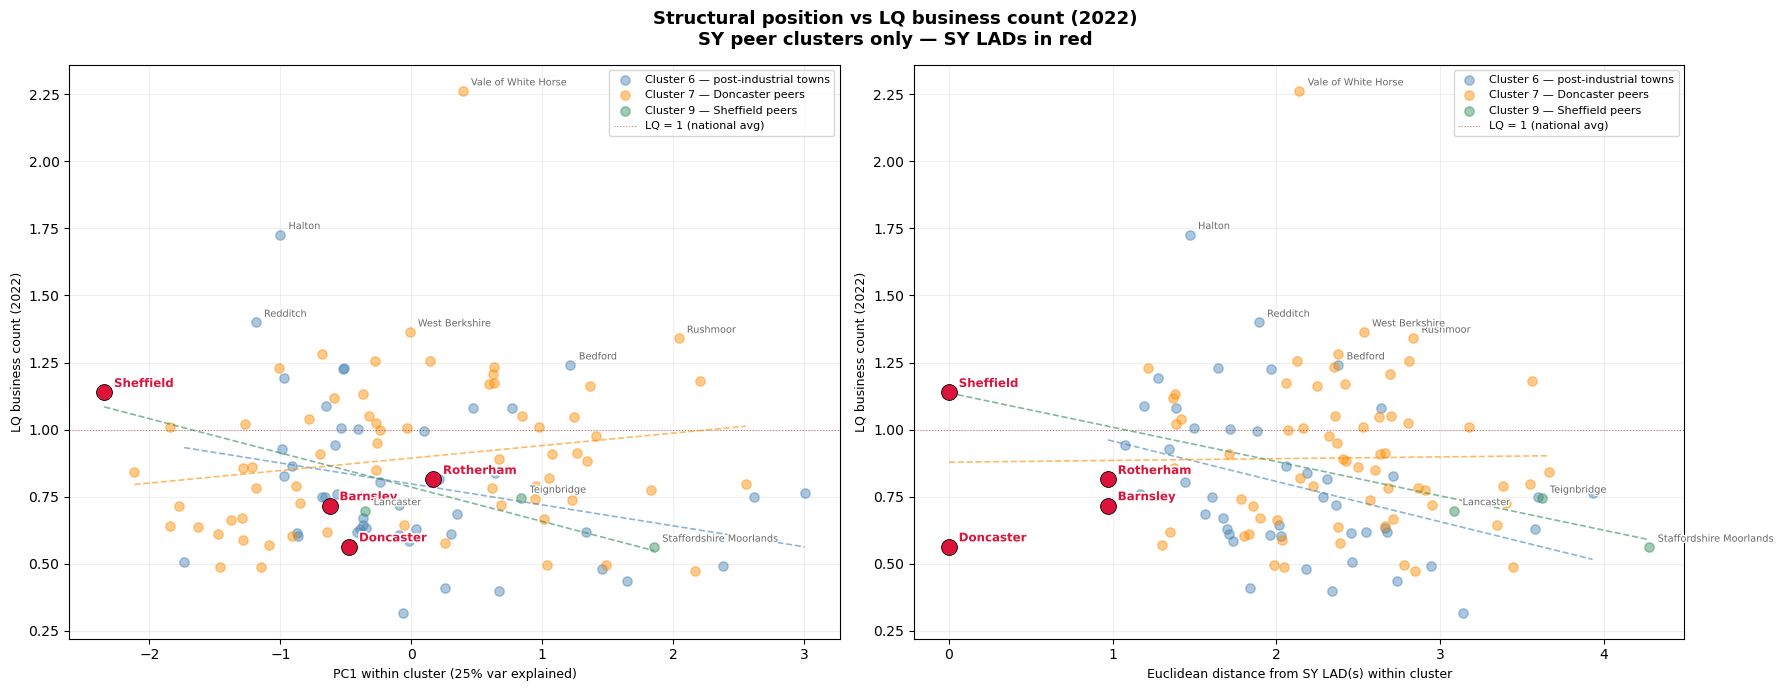

Saved: ../../output/graphs/franco/scatter_structural_lq_bus.png


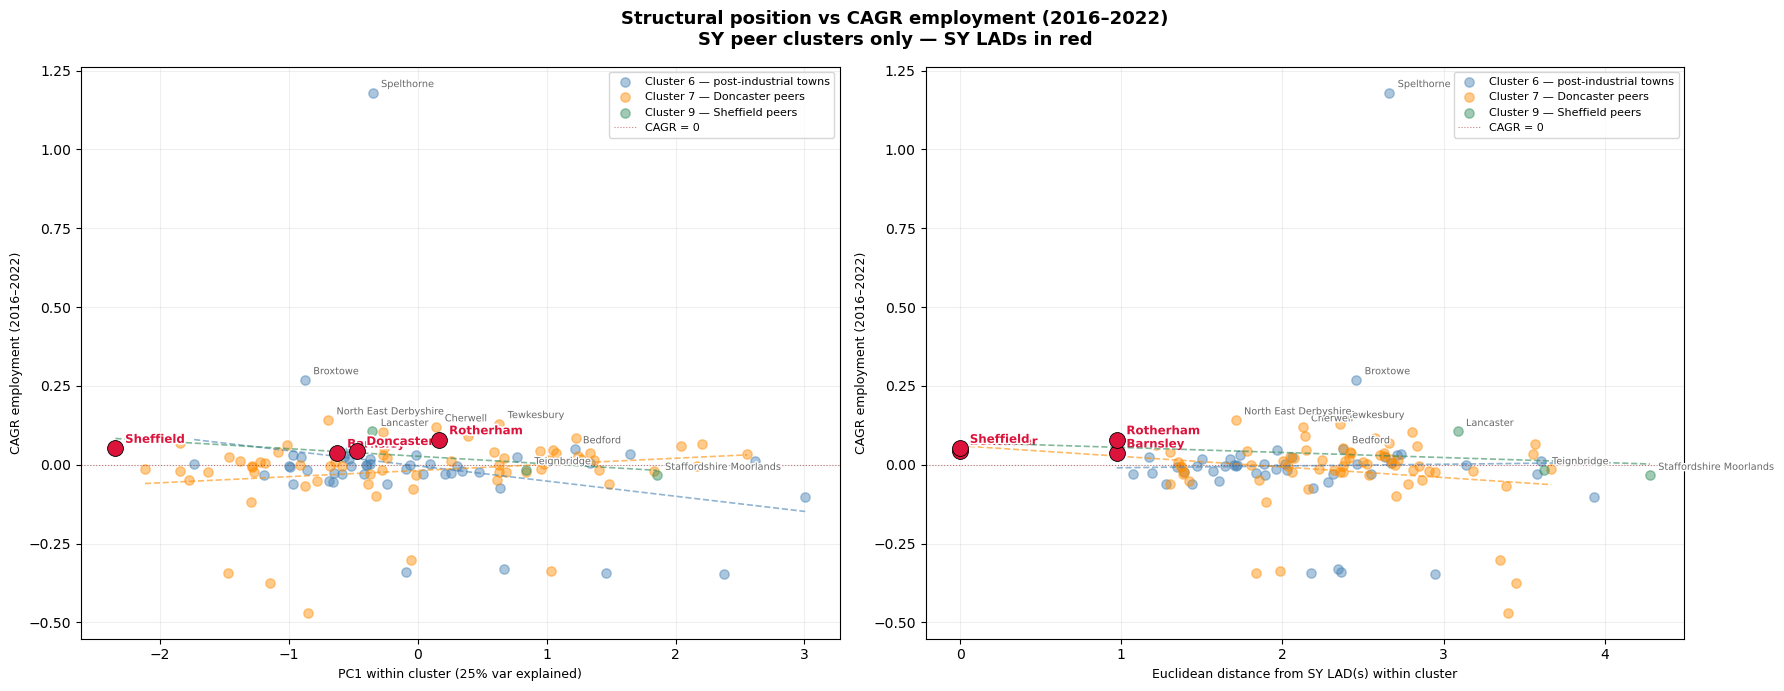

Saved: ../../output/graphs/franco/scatter_structural_cagr_emp.png


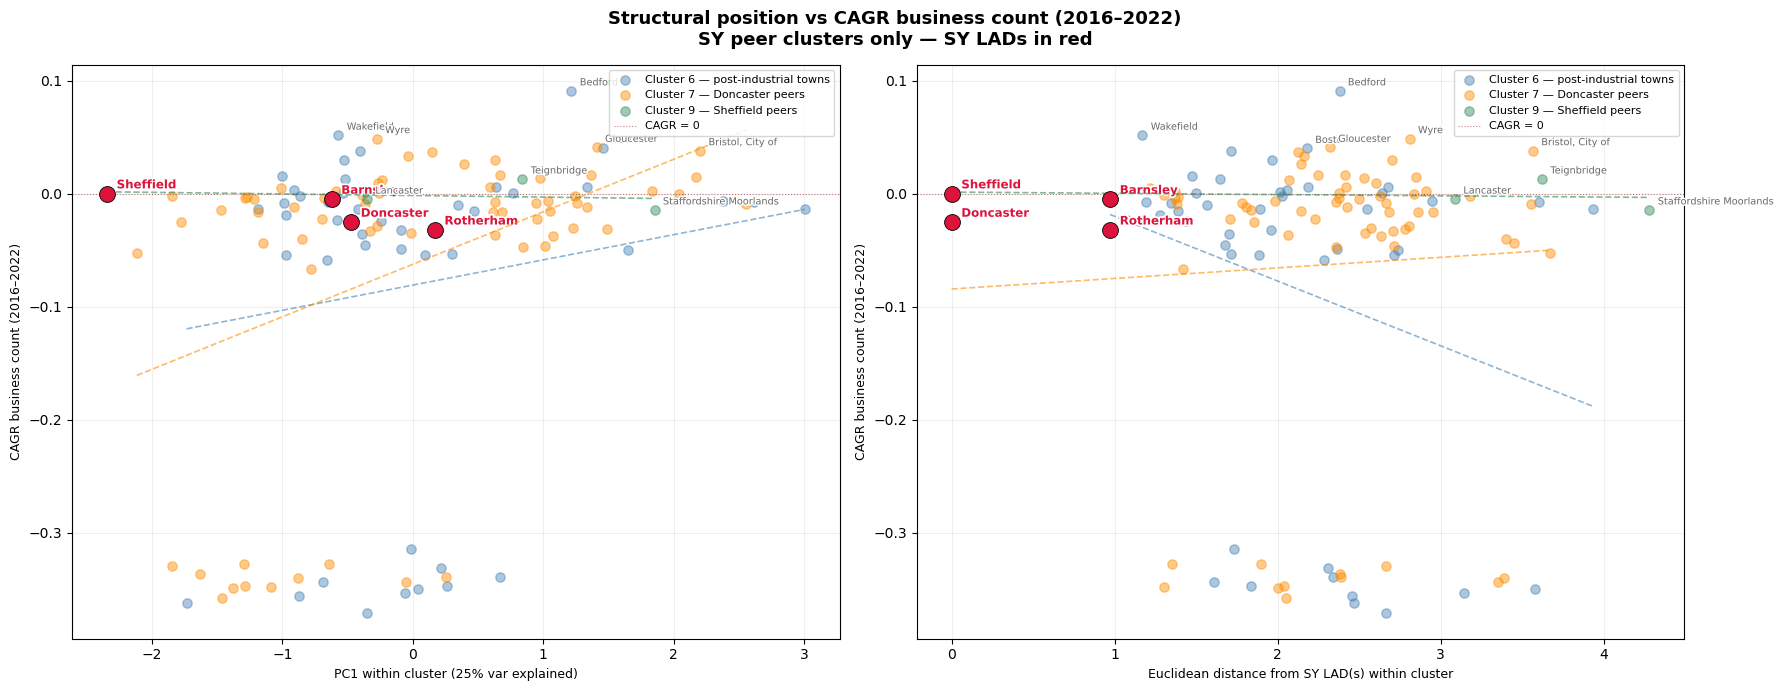

Saved: ../../output/graphs/franco/scatter_structural_cagr_bus.png


In [19]:
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
import pandas as pd
import os

OUTPUT_DIR = "../../output/graphs/franco"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
# CELL 5a — Structural position vs IS8 metrics
#
# Runs 3 times — once per metric:
#   (1) lq_emp   — employment concentration (2022)
#   (2) lq_bus   — business count concentration (2022)
#   (3) cagr_emp — employment growth (2016–2022)
#
# Each produces a side-by-side plot (PC1 vs distance) for the
# 3 SY peer clusters, with all 4 SY LADs in red.
# ============================================================

METRICS = [
    ("lq_emp",   "LQ employment (2022)"),
    ("lq_bus",   "LQ business count (2022)"),
    ("cagr_emp", "CAGR employment (2016–2022)"),
    ("cagr_bus", "CAGR business count (2016–2022)"),
]

SY_CLUSTER_IDS  = [6, 7, 9]
cluster_colours = {6: "steelblue", 7: "darkorange", 9: "seagreen"}
cluster_labels  = {
    6: "Cluster 6 — post-industrial towns",
    7: "Cluster 7 — Doncaster peers",
    9: "Cluster 9 — Sheffield peers",
}

all_codes    = lad_df.index.tolist()
all_names    = lad_df["GEOGRAPHY_NAME"].tolist()
all_clusters = lad_df["cluster"].tolist()

# Pre-compute PC1 and distance per cluster
cluster_meta = {}
for cid in SY_CLUSTER_IDS:
    c_codes = lad_df[lad_df["cluster"] == cid].index.tolist()
    c_X     = X[[all_codes.index(c) for c in c_codes]]
    sy_in_c = [c for c in SY_CODES if c in c_codes]

    pca    = PCA(n_components=1)
    pc1    = pca.fit_transform(c_X).flatten()
    var_exp = pca.explained_variance_ratio_[0] * 100

    sy_X_mean = c_X[[c_codes.index(c) for c in sy_in_c]].mean(axis=0, keepdims=True)
    dist      = cdist(c_X, sy_X_mean, metric="euclidean").flatten()

    cluster_meta[cid] = {
        "codes": c_codes, "X": c_X,
        "pc1": pc1, "var_exp": var_exp, "dist": dist,
    }

for metric, metric_label in METRICS:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(
        f"Structural position vs {metric_label}\nSY peer clusters only — SY LADs in red",
        fontsize=13, fontweight="bold"
    )

    for ax, (version, x_label_base) in zip(axes, [
        ("pc1",  "PC1 within cluster (% var explained)"),
        ("dist", "Euclidean distance from SY LAD(s) within cluster"),
    ]):
        for cid in SY_CLUSTER_IDS:
            meta     = cluster_meta[cid]
            c_codes  = meta["codes"]
            sy_lads  = [c for c in SY_CODES if c in c_codes]
            colour   = cluster_colours[cid]

            # Get metric values for this cluster
            if metric in ["lq_emp", "lq_bus"]:
                m_series = {}
                for sector in FOCUS_SECTORS:
                    lq_s = lq_lookup.xs(sector, level="IS8_SECTOR")[metric]
                    m_series[sector] = lq_s.reindex(c_codes).astype(float)
                # Average across focus sectors for this cluster
                m_vals = pd.DataFrame(m_series).mean(axis=1).values
            else:
                cagr_rows = []
                for sector in FOCUS_SECTORS:
                    col = "cagr_emp" if metric == "cagr_emp" else "cagr_bus"
                    s = (
                        panel[(panel["YEAR"] == YEAR) &
                              (panel["IS8_SECTOR"] == sector)]
                        .set_index("GEOGRAPHY_CODE")[col]
                        .astype(float)
                        .reindex(c_codes)
                    )
                    cagr_rows.append(s)
                m_vals = pd.DataFrame(cagr_rows).mean(axis=0).values

            x_vals = meta[version]
            var_exp = meta["var_exp"]

            valid   = ~np.isnan(m_vals)
            vx      = x_vals[valid]
            vy      = m_vals[valid]
            vc      = [c for c, v in zip(c_codes, valid) if v]
            vn      = [lad_df.loc[c, "GEOGRAPHY_NAME"] for c in vc]
            v_is_sy = np.array([c in sy_lads for c in vc])

            if len(vc) < 3:
                continue

            # Peers
            ax.scatter(vx[~v_is_sy], vy[~v_is_sy],
                       color=colour, alpha=0.45, s=45, zorder=2,
                       label=cluster_labels[cid])

            # Trend line within cluster
            z = np.polyfit(vx, vy, 1)
            p = np.poly1d(z)
            xl = np.linspace(vx.min(), vx.max(), 100)
            ax.plot(xl, p(xl), "--", color=colour,
                    linewidth=1.2, alpha=0.6, zorder=3)

            # SY LADs
            for xi, yi, nm, sy in zip(vx, vy, vn, v_is_sy):
                if not sy:
                    continue
                ax.scatter(xi, yi, color="crimson", s=130, zorder=6,
                           edgecolors="black", linewidths=0.6)
                ax.annotate(nm, (xi, yi),
                            xytext=(7, 4), textcoords="offset points",
                            fontsize=8.5, color="crimson", fontweight="bold",
                            path_effects=[pe.withStroke(linewidth=2.5,
                                                        foreground="white")])

            # Top-3 overperformers
            peer_y = vy[~v_is_sy]
            peer_x = vx[~v_is_sy]
            peer_n = [n for n, s in zip(vn, v_is_sy) if not s]
            for i in np.argsort(peer_y)[-3:]:
                ax.annotate(peer_n[i], (peer_x[i], peer_y[i]),
                            xytext=(6, 4), textcoords="offset points",
                            fontsize=7, color="dimgrey",
                            path_effects=[pe.withStroke(linewidth=2,
                                                        foreground="white")])

        # Reference line
        ref_val = 1.0 if metric in ["lq_emp", "lq_bus"] else 0.0
        ref_lbl = "LQ = 1 (national avg)" if metric in ["lq_emp", "lq_bus"] else "CAGR = 0"
        ax.axhline(ref_val, color="darkred", linewidth=0.8,
                   linestyle=":", alpha=0.5, label=ref_lbl)

        xl = "PC1 within cluster " + \
             f"({cluster_meta[6]['var_exp']:.0f}% var explained)" \
             if version == "pc1" else x_label_base
        ax.set_xlabel(xl, fontsize=9)
        ax.set_ylabel(metric_label, fontsize=9)
        ax.grid(alpha=0.2)

        handles, labels = ax.get_legend_handles_labels()
        ax.legend(dict(zip(labels, handles)).values(),
                  dict(zip(labels, handles)).keys(),
                  fontsize=8, loc="upper right")

    plt.tight_layout()
    fname = f"{OUTPUT_DIR}/scatter_structural_{metric}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

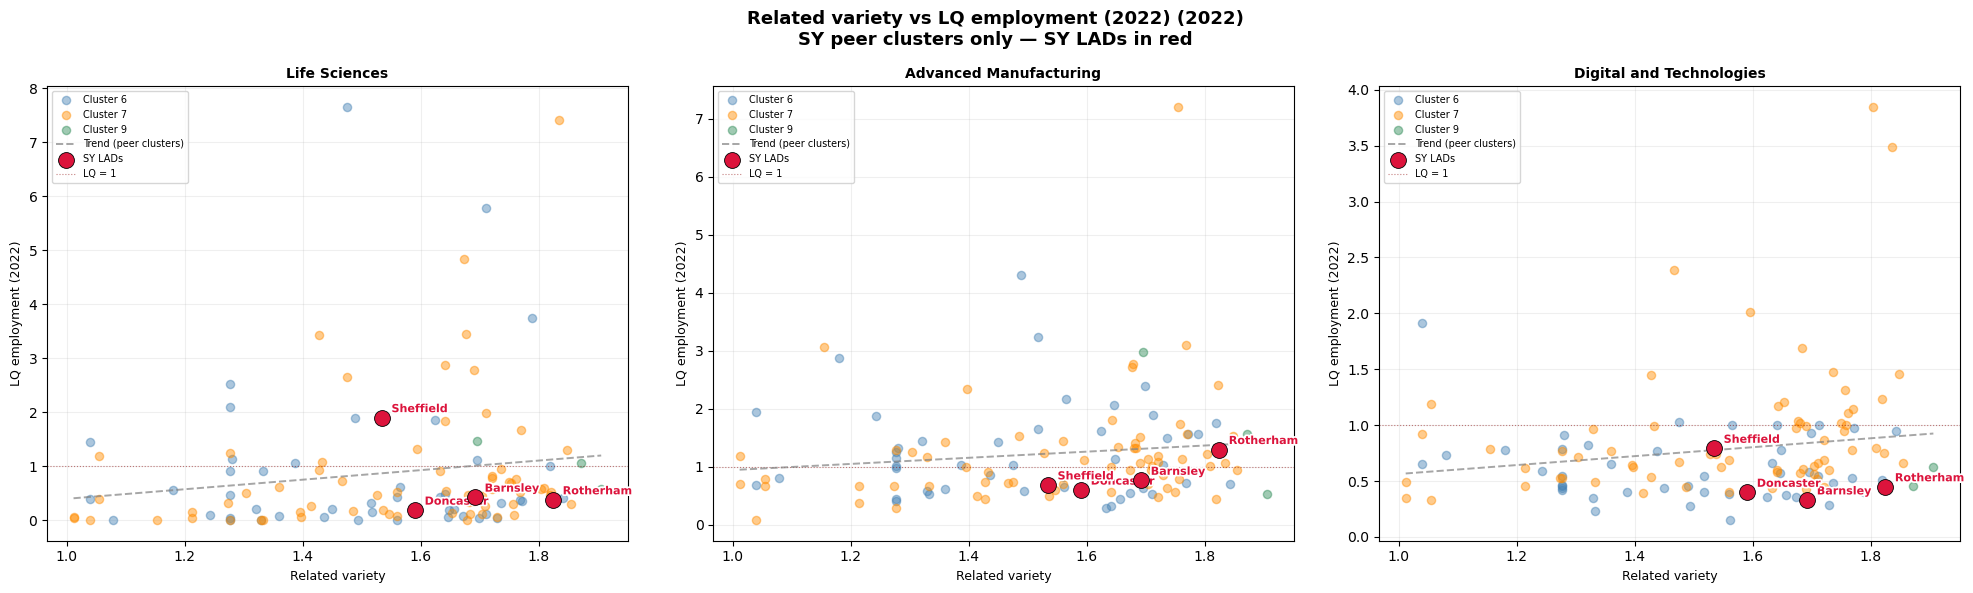

Saved: ../../output/graphs/franco/scatter_related_variety_lq_emp.png


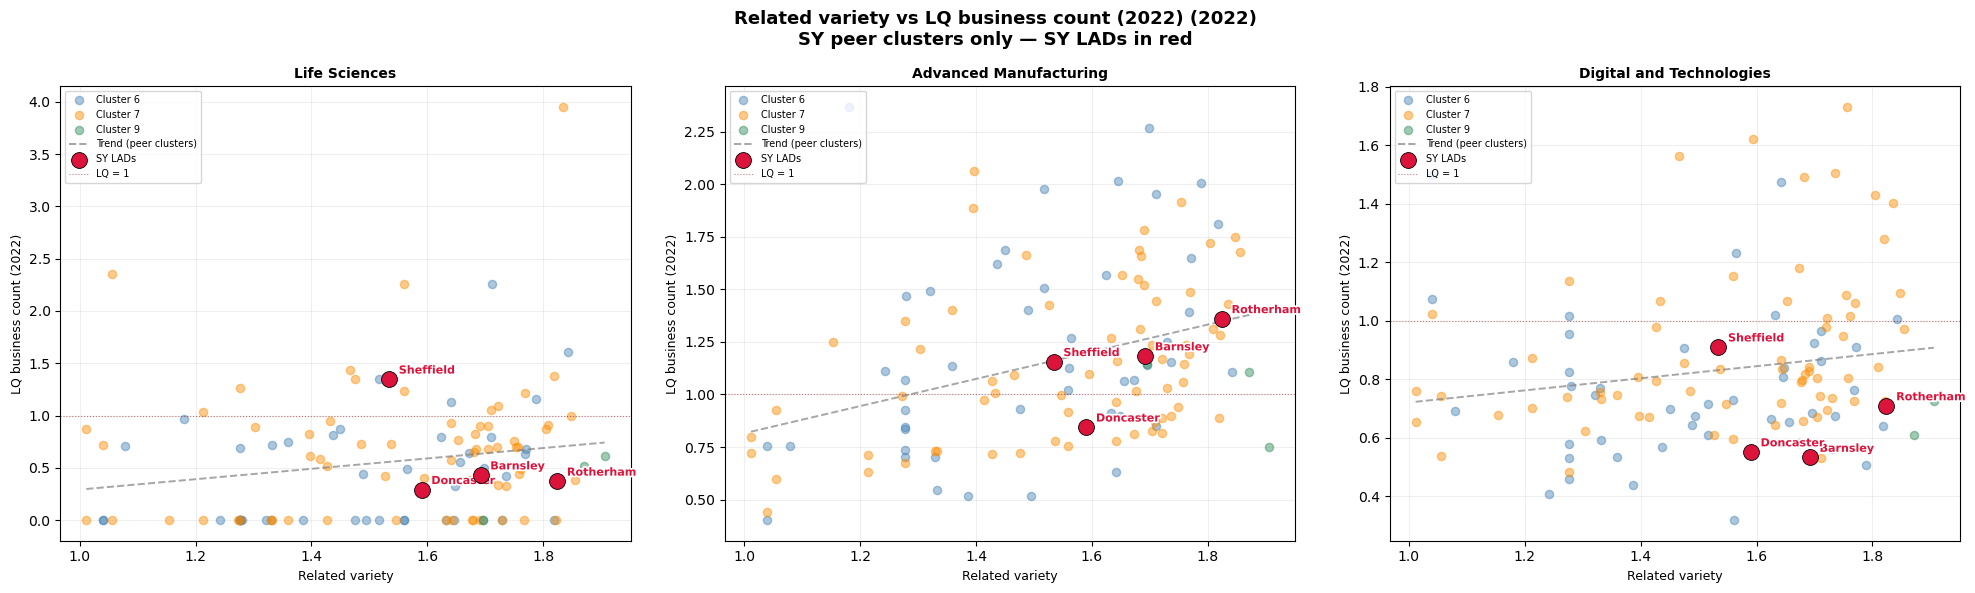

Saved: ../../output/graphs/franco/scatter_related_variety_lq_bus.png


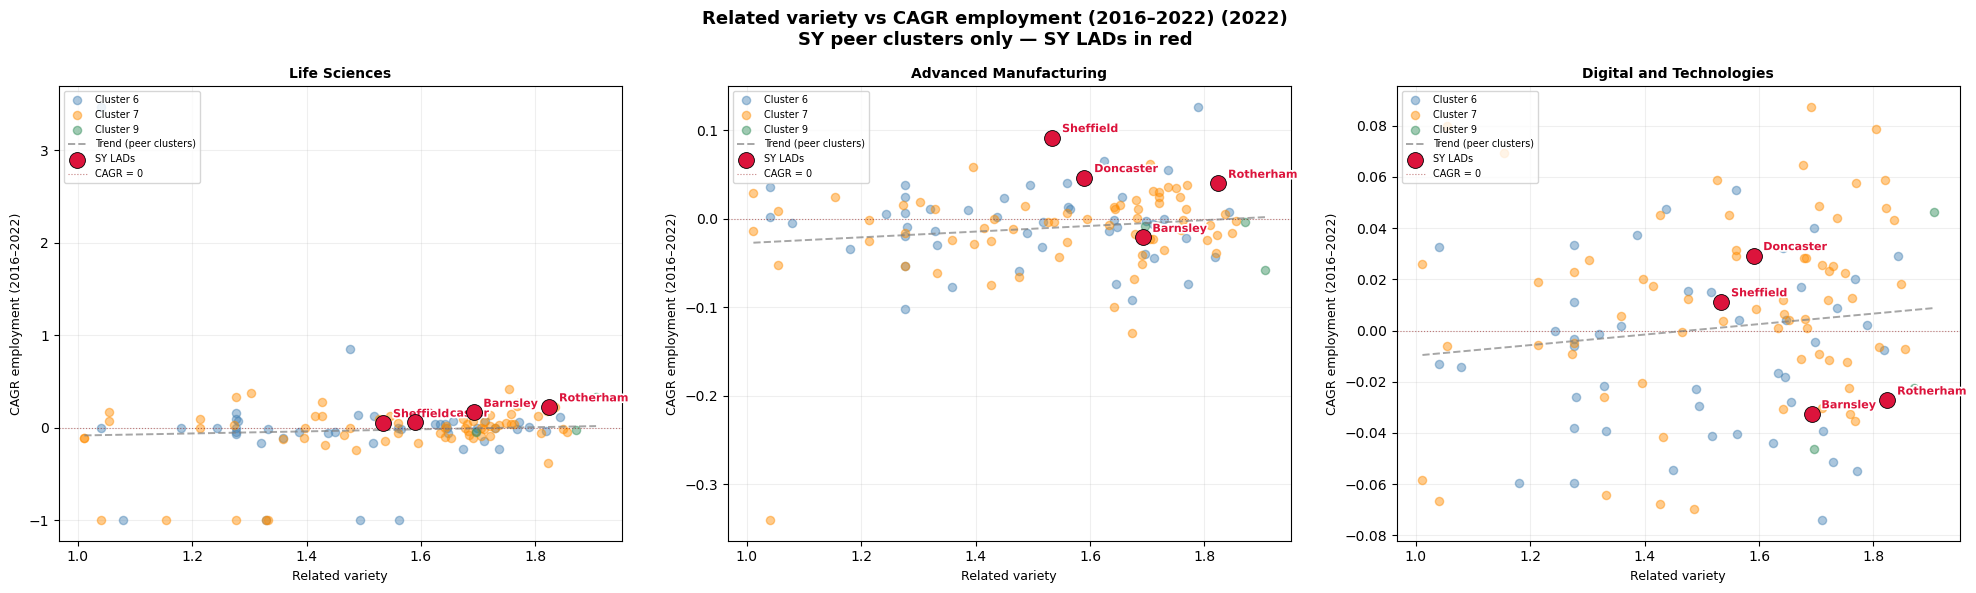

Saved: ../../output/graphs/franco/scatter_related_variety_cagr_emp.png


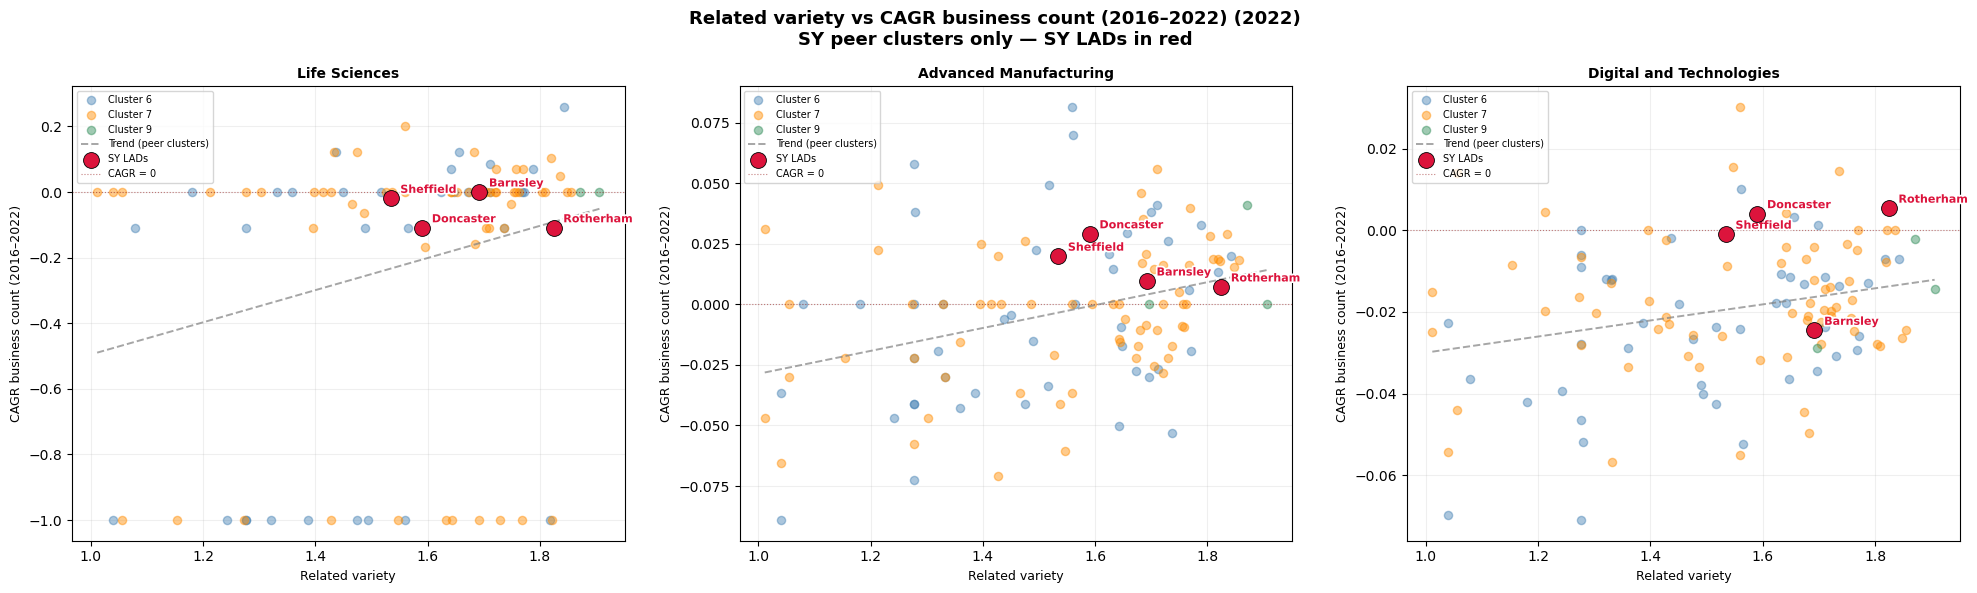

Saved: ../../output/graphs/franco/scatter_related_variety_cagr_bus.png


In [20]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
import pandas as pd
import os

OUTPUT_DIR = "../../output/graphs/franco"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
# CELL 5b — Related variety vs IS8 metrics
#
# Runs 3 times — once per metric:
#   (1) lq_emp   — employment concentration (2022)
#   (2) lq_bus   — business count concentration (2022)
#   (3) cagr_emp — employment growth (2016–2022)
#
# Each produces 3 panels (one per focus sector).
# Restricted to SY peer clusters. SY LADs in red.
# ============================================================

METRICS = [
    ("lq_emp",   "LQ employment (2022)"),
    ("lq_bus",   "LQ business count (2022)"),
    ("cagr_emp", "CAGR employment (2016–2022)"),
    ("cagr_bus", "CAGR business count (2016–2022)"),
]

cluster_colours = {6: "steelblue", 7: "darkorange", 9: "seagreen"}
sy_cluster_codes = lad_df[lad_df["cluster"].isin([6, 7, 9])].index.tolist()

# Related variety — one value per LAD, restricted to SY clusters
rv_df = (
    panel[panel["YEAR"] == YEAR]
    .drop_duplicates(subset="GEOGRAPHY_CODE")
    .set_index("GEOGRAPHY_CODE")[["GEOGRAPHY_NAME", "related_variety"]]
    .dropna(subset=["related_variety"])
)
rv_df    = rv_df[rv_df.index.isin(sy_cluster_codes)]
rv_codes = rv_df.index.tolist()
rv_names = rv_df["GEOGRAPHY_NAME"].tolist()
rv_vals  = rv_df["related_variety"].astype(float).values
is_sy_rv = np.array([c in SY_CODES for c in rv_codes])

for metric, metric_label in METRICS:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(
        f"Related variety vs {metric_label} (2022)\nSY peer clusters only — SY LADs in red",
        fontsize=13, fontweight="bold"
    )

    for ax, sector in zip(axes, FOCUS_SECTORS):

        # Get metric values per LAD for this sector
        if metric in ["lq_emp", "lq_bus"]:
            m_vals = (
                lq_lookup.xs(sector, level="IS8_SECTOR")[metric]
                .reindex(rv_codes)
                .astype(float)
                .values
            )
        else:
            col = "cagr_emp" if metric == "cagr_emp" else "cagr_bus"
            m_vals = (
                panel[(panel["YEAR"] == YEAR) &
                      (panel["IS8_SECTOR"] == sector)]
                .set_index("GEOGRAPHY_CODE")[col]
                .astype(float)
                .reindex(rv_codes)
                .values
            )

        valid   = ~np.isnan(m_vals) & ~np.isnan(rv_vals)
        v_rv    = rv_vals[valid]
        v_m     = m_vals[valid]
        v_codes = [c for c, v in zip(rv_codes, valid) if v]
        v_names = [n for n, v in zip(rv_names, valid) if v]
        v_is_sy = np.array([c in SY_CODES for c in v_codes])

        # Peers coloured by cluster
        for cid, col in cluster_colours.items():
            cid_codes = lad_df[lad_df["cluster"] == cid].index.tolist()
            mask = np.array([c in cid_codes and not s
                             for c, s in zip(v_codes, v_is_sy)])
            if mask.sum() == 0:
                continue
            ax.scatter(v_rv[mask], v_m[mask], color=col, alpha=0.45,
                       s=35, zorder=2, label=f"Cluster {cid}")

        # Trend line
        z = np.polyfit(v_rv, v_m, 1)
        p = np.poly1d(z)
        xl = np.linspace(v_rv.min(), v_rv.max(), 200)
        ax.plot(xl, p(xl), "--", color="grey", linewidth=1.4,
                alpha=0.7, label="Trend (peer clusters)", zorder=3)

        # SY LADs
        sy_rv = v_rv[v_is_sy]
        sy_m  = v_m[v_is_sy]
        sy_nm = [n for n, s in zip(v_names, v_is_sy) if s]

        ax.scatter(sy_rv, sy_m, color="crimson", s=130, zorder=6,
                   edgecolors="black", linewidths=0.6, label="SY LADs")
        for xi, yi, nm in zip(sy_rv, sy_m, sy_nm):
            ax.annotate(nm, (xi, yi),
                        xytext=(7, 4), textcoords="offset points",
                        fontsize=8, color="crimson", fontweight="bold",
                        path_effects=[pe.withStroke(linewidth=2.5,
                                                    foreground="white")])

        # Reference line
        ref_val = 1.0 if metric in ["lq_emp", "lq_bus"] else 0.0
        ref_lbl = "LQ = 1" if metric in ["lq_emp", "lq_bus"] else "CAGR = 0"
        ax.axhline(ref_val, color="darkred", linewidth=0.8,
                   linestyle=":", alpha=0.5, label=ref_lbl)

        ax.set_xlabel("Related variety", fontsize=9)
        ax.set_ylabel(metric_label, fontsize=9)
        ax.set_title(sector, fontsize=10, fontweight="bold")

        handles, labels = ax.get_legend_handles_labels()
        ax.legend(dict(zip(labels, handles)).values(),
                  dict(zip(labels, handles)).keys(),
                  fontsize=7, loc="upper left")
        ax.grid(alpha=0.2)

    plt.tight_layout()
    fname = f"{OUTPUT_DIR}/scatter_related_variety_{metric}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

lq_emp: 2450 non-null values, mean=0.9373
lq_bus: 2450 non-null values, mean=0.7480
cagr_emp: 2158 non-null values, mean=-0.0055
cagr_bus: 2040 non-null values, mean=-0.0212


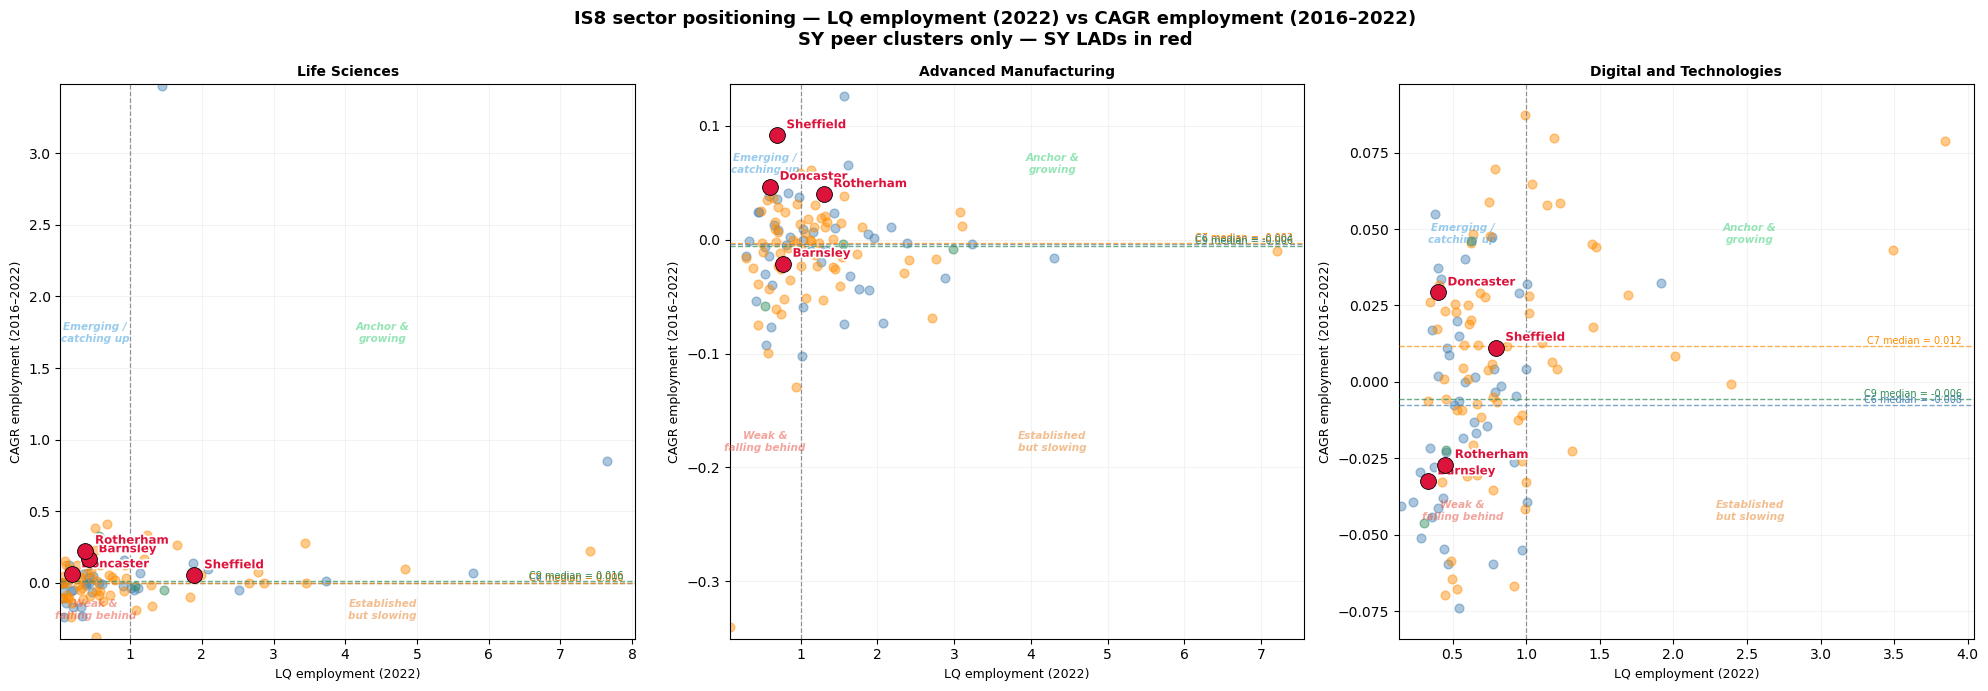

Saved: ../../output/graphs/franco/quadrant_lq_emp_vs_cagr_emp.png


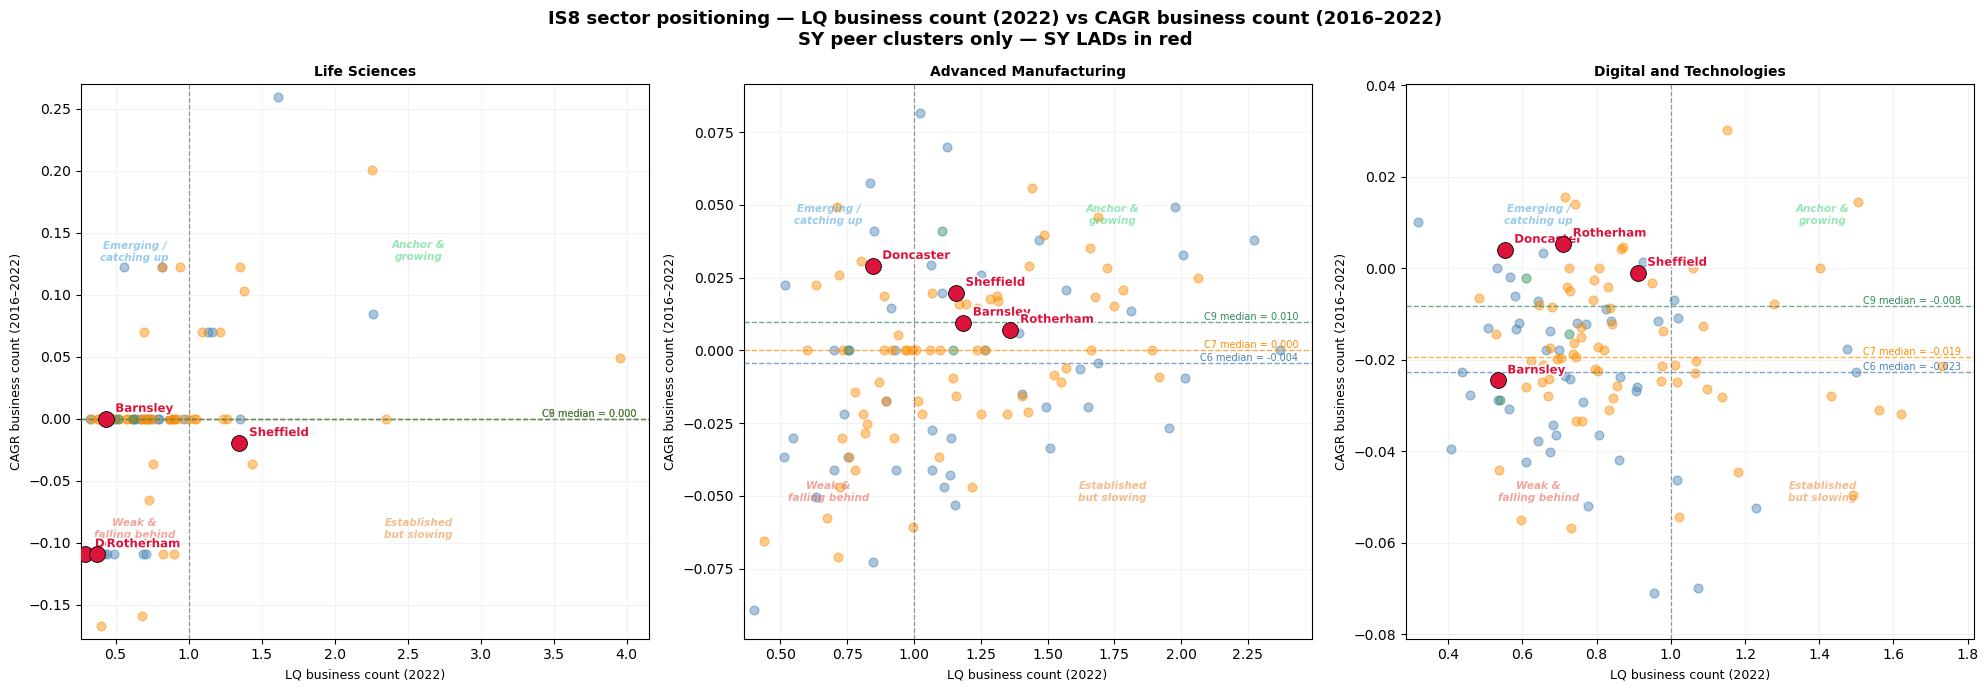

Saved: ../../output/graphs/franco/quadrant_lq_bus_vs_cagr_bus.png


In [26]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
import os

OUTPUT_DIR = "../../output/graphs/franco"
os.makedirs(OUTPUT_DIR, exist_ok=True)

QUADRANT_LABELS = {
    "Q1": ("Anchor &\ngrowing",       "top-right",    "#2ecc71"),
    "Q2": ("Emerging /\ncatching up", "top-left",     "#3498db"),
    "Q3": ("Weak &\nfalling behind",  "bottom-left",  "#e74c3c"),
    "Q4": ("Established\nbut slowing","bottom-right", "#e67e22"),
}

# Get LQ and CAGR at LAD level for 2022
lq_cagr = (
    panel[panel["YEAR"] == YEAR]
    .set_index(["GEOGRAPHY_CODE", "IS8_SECTOR"])
    [["GEOGRAPHY_NAME", "lq_emp", "lq_bus", "cagr_emp", "cagr_bus"]]
    .copy()
)

# Diagnostics
for col in ["lq_emp", "lq_bus", "cagr_emp", "cagr_bus"]:
    n_valid = lq_cagr[col].notna().sum()
    print(f"{col}: {n_valid} non-null values, mean={lq_cagr[col].mean():.4f}")

METRIC_PAIRS = [
    ("lq_emp", "cagr_emp", "LQ employment (2022)",      "CAGR employment (2016–2022)"),
    ("lq_bus", "cagr_bus", "LQ business count (2022)",  "CAGR business count (2016–2022)"),
]

for lq_metric, cagr_metric, lq_label, cagr_label in METRIC_PAIRS:

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    fig.suptitle(
        f"IS8 sector positioning — {lq_label} vs {cagr_label}\n"
        "SY peer clusters only — SY LADs in red",
        fontsize=13, fontweight="bold"
    )

    for ax, sector in zip(axes, FOCUS_SECTORS):

        # -------------------------------
        # Restrict to SY peer clusters
        # -------------------------------
        sy_cluster_ids = [6, 7, 9]
        sy_cluster_codes = lad_df[lad_df["cluster"].isin(sy_cluster_ids)].index.tolist()

        sec_df = lq_cagr.xs(sector, level="IS8_SECTOR").copy()
        sec_df = sec_df[sec_df.index.isin(sy_cluster_codes)]

        # -------------------------------
        # Dynamic metrics (FIXED)
        # -------------------------------
        sec_df = sec_df.dropna(subset=[lq_metric, cagr_metric])
        sec_df = sec_df[sec_df[lq_metric] > 0]

        lq_vals   = sec_df[lq_metric].astype(float).values
        cagr_vals = sec_df[cagr_metric].astype(float).values
        codes     = sec_df.index.tolist()
        names     = sec_df["GEOGRAPHY_NAME"].tolist()
        is_sy     = np.array([c in SY_CODES for c in codes])

        # -------------------------------
        # Cluster-specific medians (NEW)
        # -------------------------------
        cluster_colours = {6: "steelblue", 7: "darkorange", 9: "seagreen"}
        cluster_medians = {}

        for cid in sy_cluster_ids:
            cid_codes = lad_df[lad_df["cluster"] == cid].index.tolist()

            cid_df = lq_cagr.xs(sector, level="IS8_SECTOR").copy()
            cid_df = cid_df[cid_df.index.isin(cid_codes)]
            cid_df = cid_df.dropna(subset=[cagr_metric])

            if len(cid_df) > 0:
                cluster_medians[cid] = np.nanmedian(cid_df[cagr_metric])

        # -------------------------------
        # Plot clusters
        # -------------------------------
        for cid, col in cluster_colours.items():
            cid_codes = lad_df[lad_df["cluster"] == cid].index.tolist()
            mask = np.array([c in cid_codes and not s for c, s in zip(codes, is_sy)])
            if mask.sum() == 0:
                continue
            ax.scatter(lq_vals[mask], cagr_vals[mask],
                       color=col, alpha=0.45, s=40, zorder=2,
                       label=f"Cluster {cid}")

        # -------------------------------
        # Reference lines
        # -------------------------------
        ax.axvline(1.0, color="dimgrey", linewidth=0.9,
                   linestyle="--", alpha=0.7, zorder=3)

        for cid, med in cluster_medians.items():
            ax.axhline(
                med,
                color=cluster_colours[cid],
                linestyle="--",
                linewidth=1.0,
                alpha=0.7,
                zorder=3
            )

        # -------------------------------
        # Axis limits
        # -------------------------------
        x_min, x_max = lq_vals.min() * 0.9,  lq_vals.max() * 1.05
        y_min, y_max = cagr_vals.min() - 0.01, cagr_vals.max() + 0.01

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)

        # -------------------------------
        # Quadrant labels (still useful)
        # -------------------------------
        mid_x_left  = (x_min + 1.0) / 2
        mid_x_right = (1.0 + x_max) / 2
        mid_y_top   = (np.mean(list(cluster_medians.values())) + y_max) / 2
        mid_y_bot   = (y_min + np.mean(list(cluster_medians.values()))) / 2

        for (_, (qtxt, pos, col)) in QUADRANT_LABELS.items():
            qx = mid_x_right if "right" in pos else mid_x_left
            qy = mid_y_top   if "top"   in pos else mid_y_bot
            ax.text(qx, qy, qtxt, ha="center", va="center",
                    fontsize=7.5, color=col, alpha=0.5,
                    style="italic", fontweight="bold")

        # -------------------------------
        # SY LADs
        # -------------------------------
        sy_lq   = lq_vals[is_sy]
        sy_cagr = cagr_vals[is_sy]
        sy_nm   = [n for n, s in zip(names, is_sy) if s]

        ax.scatter(sy_lq, sy_cagr, color="crimson", s=130,
                   zorder=6, edgecolors="black", linewidths=0.6)

        for xi, yi, nm in zip(sy_lq, sy_cagr, sy_nm):
            ax.annotate(
                nm, (xi, yi),
                xytext=(7, 5), textcoords="offset points",
                fontsize=8.5, color="crimson", fontweight="bold",
                path_effects=[pe.withStroke(linewidth=2.5, foreground="white")]
            )

        # -------------------------------
        # Optional: label cluster medians
        # -------------------------------
        for cid, med in cluster_medians.items():
            ax.text(
                x_max * 0.98,
                med,
                f"C{cid} median = {med:.3f}",
                ha="right", va="bottom",
                fontsize=7,
                color=cluster_colours[cid]
            )

        ax.set_xlabel(lq_label, fontsize=9)
        ax.set_ylabel(cagr_label, fontsize=9)
        ax.set_title(sector, fontsize=10, fontweight="bold")
        ax.grid(alpha=0.15)

    plt.tight_layout()
    fname = f"{OUTPUT_DIR}/quadrant_{lq_metric}_vs_{cagr_metric}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Saved: {fname}")

lq_emp: 2450 non-null values, mean=0.9373
lq_bus: 2450 non-null values, mean=0.7480
cagr_emp: 2158 non-null values, mean=-0.0055
cagr_bus: 2040 non-null values, mean=-0.0212


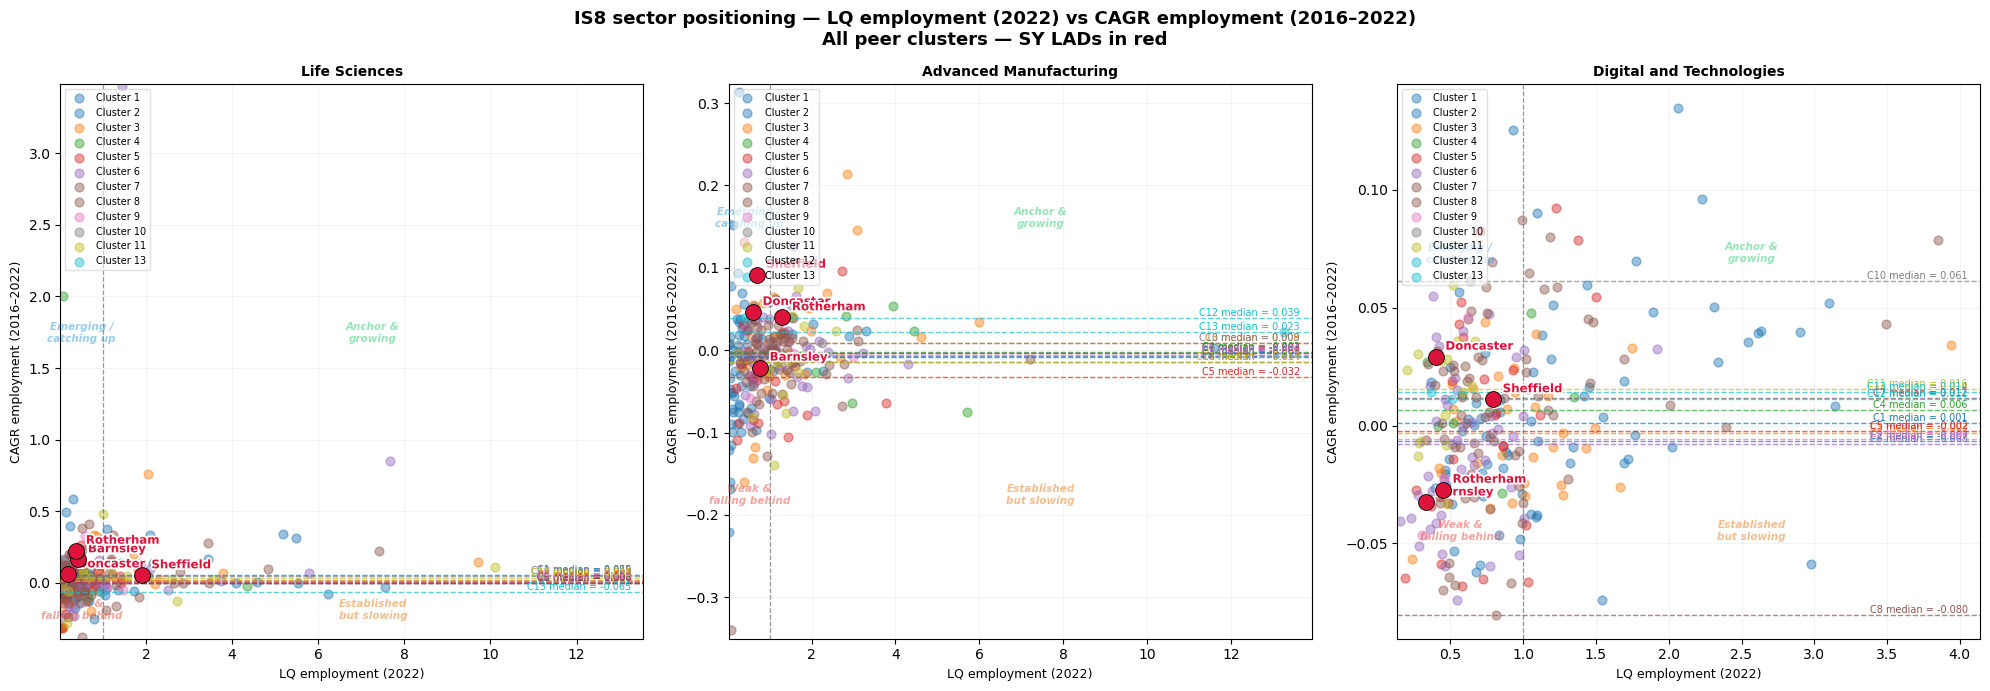

Saved: ../../output/graphs/franco/quadrant_lq_emp_vs_cagr_emp.png


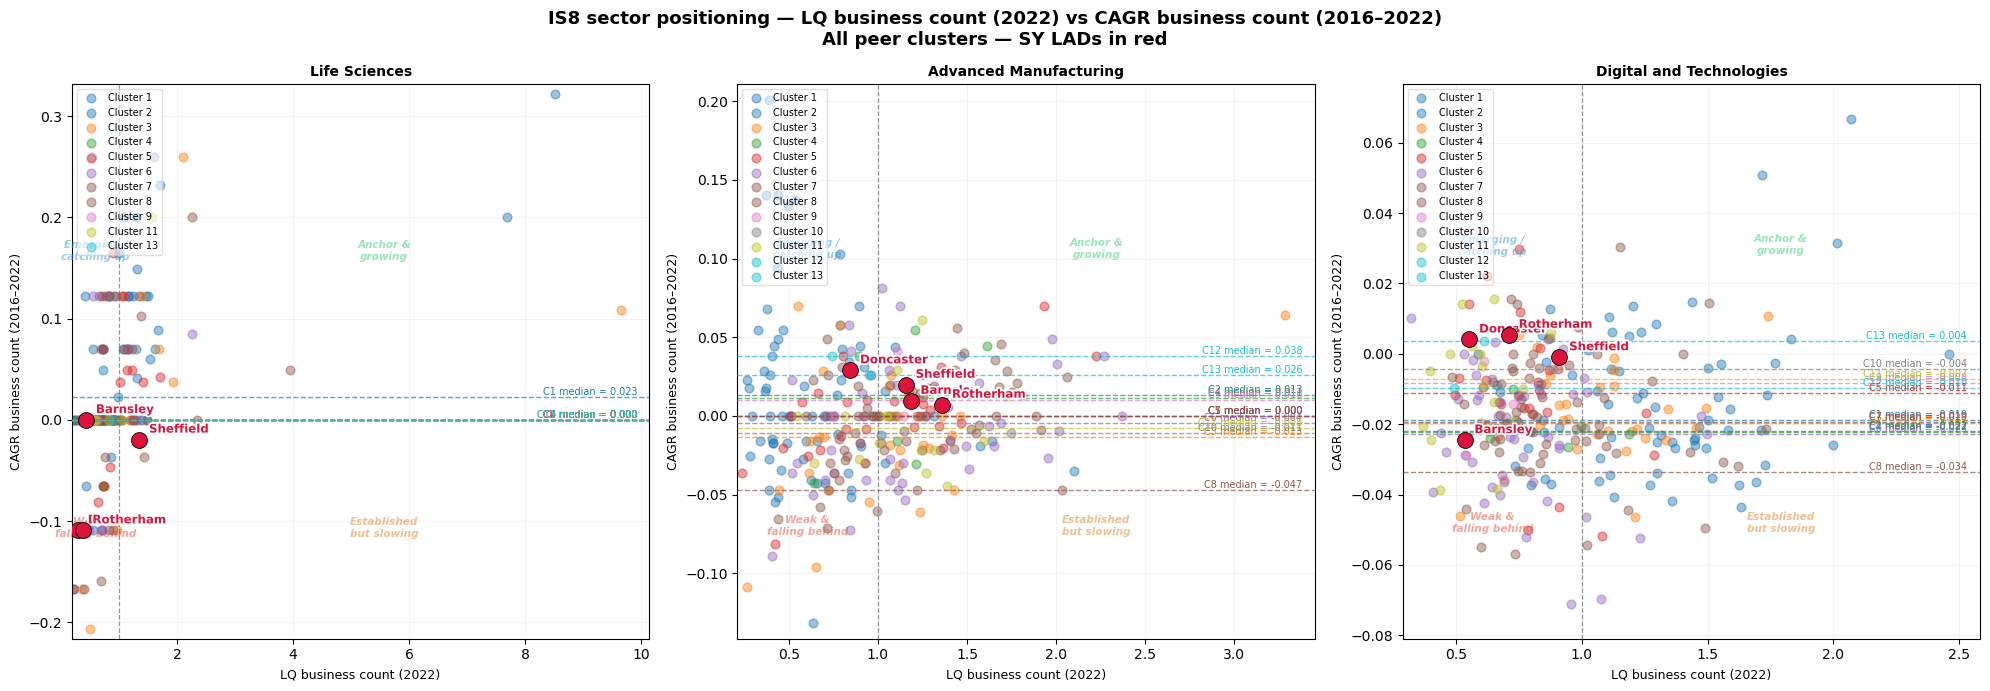

Saved: ../../output/graphs/franco/quadrant_lq_bus_vs_cagr_bus.png


In [22]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.cm as cm
import numpy as np
import os

OUTPUT_DIR = "../../output/graphs/franco"
os.makedirs(OUTPUT_DIR, exist_ok=True)

QUADRANT_LABELS = {
    "Q1": ("Anchor &\ngrowing",       "top-right",    "#2ecc71"),
    "Q2": ("Emerging /\ncatching up", "top-left",     "#3498db"),
    "Q3": ("Weak &\nfalling behind",  "bottom-left",  "#e74c3c"),
    "Q4": ("Established\nbut slowing","bottom-right", "#e67e22"),
}

# Get LQ and CAGR at LAD level for 2022
lq_cagr = (
    panel[panel["YEAR"] == YEAR]
    .set_index(["GEOGRAPHY_CODE", "IS8_SECTOR"])
    [["GEOGRAPHY_NAME", "lq_emp", "lq_bus", "cagr_emp", "cagr_bus"]]
    .copy()
)

# Diagnostics
for col in ["lq_emp", "lq_bus", "cagr_emp", "cagr_bus"]:
    n_valid = lq_cagr[col].notna().sum()
    print(f"{col}: {n_valid} non-null values, mean={lq_cagr[col].mean():.4f}")

METRIC_PAIRS = [
    ("lq_emp", "cagr_emp", "LQ employment (2022)",      "CAGR employment (2016–2022)"),
    ("lq_bus", "cagr_bus", "LQ business count (2022)",  "CAGR business count (2016–2022)"),
]

# -----------------------------------------------
# Build cluster IDs and colour mapping dynamically
# -----------------------------------------------
all_cluster_ids = sorted(lad_df["cluster"].dropna().unique().astype(int).tolist())
cmap = cm.get_cmap("tab10", len(all_cluster_ids))
cluster_colours = {cid: cmap(i) for i, cid in enumerate(all_cluster_ids)}

for lq_metric, cagr_metric, lq_label, cagr_label in METRIC_PAIRS:

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    fig.suptitle(
        f"IS8 sector positioning — {lq_label} vs {cagr_label}\n"
        "All peer clusters — SY LADs in red",
        fontsize=13, fontweight="bold"
    )

    for ax, sector in zip(axes, FOCUS_SECTORS):

        # -----------------------------------------------
        # All cluster codes (no longer restricted to SY peers)
        # -----------------------------------------------
        all_cluster_codes = lad_df.index.tolist()

        sec_df = lq_cagr.xs(sector, level="IS8_SECTOR").copy()
        sec_df = sec_df[sec_df.index.isin(all_cluster_codes)]

        sec_df = sec_df.dropna(subset=[lq_metric, cagr_metric])
        sec_df = sec_df[sec_df[lq_metric] > 0]

        lq_vals   = sec_df[lq_metric].astype(float).values
        cagr_vals = sec_df[cagr_metric].astype(float).values
        codes     = sec_df.index.tolist()
        names     = sec_df["GEOGRAPHY_NAME"].tolist()
        is_sy     = np.array([c in SY_CODES for c in codes])

        # -----------------------------------------------
        # Cluster-specific medians — all clusters
        # -----------------------------------------------
        cluster_medians = {}

        for cid in all_cluster_ids:
            cid_codes = lad_df[lad_df["cluster"] == cid].index.tolist()

            cid_df = lq_cagr.xs(sector, level="IS8_SECTOR").copy()
            cid_df = cid_df[cid_df.index.isin(cid_codes)]
            cid_df = cid_df.dropna(subset=[cagr_metric])

            if len(cid_df) > 0:
                cluster_medians[cid] = np.nanmedian(cid_df[cagr_metric])

        # -----------------------------------------------
        # Plot clusters
        # -----------------------------------------------
        for cid, col in cluster_colours.items():
            cid_codes = lad_df[lad_df["cluster"] == cid].index.tolist()
            mask = np.array([c in cid_codes and not s for c, s in zip(codes, is_sy)])
            if mask.sum() == 0:
                continue
            ax.scatter(lq_vals[mask], cagr_vals[mask],
                       color=col, alpha=0.45, s=40, zorder=2,
                       label=f"Cluster {cid}")

        # -----------------------------------------------
        # Reference lines
        # -----------------------------------------------
        ax.axvline(1.0, color="dimgrey", linewidth=0.9,
                   linestyle="--", alpha=0.7, zorder=3)

        for cid, med in cluster_medians.items():
            ax.axhline(
                med,
                color=cluster_colours[cid],
                linestyle="--",
                linewidth=1.0,
                alpha=0.7,
                zorder=3
            )

        # -----------------------------------------------
        # Axis limits
        # -----------------------------------------------
        x_min, x_max = lq_vals.min() * 0.9,  lq_vals.max() * 1.05
        y_min, y_max = cagr_vals.min() - 0.01, cagr_vals.max() + 0.01

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)

        # -----------------------------------------------
        # Quadrant labels
        # -----------------------------------------------
        mid_x_left  = (x_min + 1.0) / 2
        mid_x_right = (1.0 + x_max) / 2
        mid_y_top   = (np.mean(list(cluster_medians.values())) + y_max) / 2
        mid_y_bot   = (y_min + np.mean(list(cluster_medians.values()))) / 2

        for (_, (qtxt, pos, col)) in QUADRANT_LABELS.items():
            qx = mid_x_right if "right" in pos else mid_x_left
            qy = mid_y_top   if "top"   in pos else mid_y_bot
            ax.text(qx, qy, qtxt, ha="center", va="center",
                    fontsize=7.5, color=col, alpha=0.5,
                    style="italic", fontweight="bold")

        # -----------------------------------------------
        # SY LADs
        # -----------------------------------------------
        sy_lq   = lq_vals[is_sy]
        sy_cagr = cagr_vals[is_sy]
        sy_nm   = [n for n, s in zip(names, is_sy) if s]

        ax.scatter(sy_lq, sy_cagr, color="crimson", s=130,
                   zorder=6, edgecolors="black", linewidths=0.6)

        for xi, yi, nm in zip(sy_lq, sy_cagr, sy_nm):
            ax.annotate(
                nm, (xi, yi),
                xytext=(7, 5), textcoords="offset points",
                fontsize=8.5, color="crimson", fontweight="bold",
                path_effects=[pe.withStroke(linewidth=2.5, foreground="white")]
            )

        # -----------------------------------------------
        # Label cluster medians (right edge)
        # -----------------------------------------------
        for cid, med in cluster_medians.items():
            ax.text(
                x_max * 0.98,
                med,
                f"C{cid} median = {med:.3f}",
                ha="right", va="bottom",
                fontsize=7,
                color=cluster_colours[cid]
            )

        ax.set_xlabel(lq_label, fontsize=9)
        ax.set_ylabel(cagr_label, fontsize=9)
        ax.set_title(sector, fontsize=10, fontweight="bold")
        ax.grid(alpha=0.15)

        ax.legend(fontsize=7, loc="upper left", framealpha=0.6)

    plt.tight_layout()
    fname = f"{OUTPUT_DIR}/quadrant_{lq_metric}_vs_{cagr_metric}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Saved: {fname}")

## Narrative Structure

### 1. Opening: South Yorkshire's IS8 footprint is internally differentiated
Don't start with the MCA aggregate — start by establishing that SY is not one economy. The dendrogram already showed this: Sheffield clusters separately from Barnsley/Doncaster/Rotherham. Use this as the framing device. Everything that follows is structured around that internal differentiation.

---

### 2. Life Sciences — anchor in Sheffield, absent elsewhere

**Evidence chain:**
- 5c (emp): Sheffield above LQ=1, the other three compressed at bottom-left — weak and falling behind
- 5a (lq_emp): Sheffield above cluster trend, peers like Broxtowe and Halton show what's achievable
- 5b (lq_emp): Sheffield converts related variety, others don't despite similar variety values
- 5c (bus): Sheffield's firm base is contracting (CAGR bus negative) even as employment holds
- 5b (lq_bus): Barnsley/Doncaster/Rotherham have near-zero business count LQ — not just weak employment but virtually no firm base

**The argument:** Sheffield has an established Life Sciences anchor driven by the university and teaching hospitals — it overperforms relative to structural peers. The other three LADs have the industrial diversity to support Life Sciences (related variety is there) but no firm base and no employment trajectory. The barrier is institutional: without an anchor organisation to seed the ecosystem, related variety alone doesn't convert.

---

### 3. Advanced Manufacturing — present but fragmented, positive momentum

**Evidence chain:**
- 5a (lq_emp): SY LADs broadly on trend — performing as structural position predicts
- 5a (lq_bus): Rotherham and Barnsley above trend on business count — more firms than structural position would suggest
- 5b (lq_bus): All four on or above trend — related variety is converting into firm presence
- 5c (bus): All four above cluster medians on CAGR bus — firm counts growing
- 5c (emp): Sheffield and Doncaster in emerging quadrant, positive employment CAGR

**The argument:** Advanced Manufacturing is the most structurally grounded story. Firms are present in proportion to industrial diversity, employment is growing above national median, and business counts are increasing. The constraint is depth not presence — the gap between business LQ (1.69 MCA aggregate) and employment LQ (1.16) points to SME fragmentation. The adjacency to Clean Energy via the Humber supply chain is the forward-looking opportunity.

---

### 4. Digital & Technologies — high potential, systemic underconversion

**Evidence chain:**
- 5b (lq_emp): All four below trend despite sitting at high end of related variety — the clearest underperformance signal in the dataset
- 5b (cagr_emp): Barnsley and Rotherham below trend and negative — losing ground
- 5c (emp): Rotherham and Barnsley in weak/falling behind quadrant
- 5b (lq_bus): All four below trend on business count
- 5c (bus): Barnsley clearly negative CAGR bus, Doncaster and Rotherham marginally positive

**The argument:** Digital is the most analytically distinctive case. The related variety is there — SY's industrial base is cognitively adjacent to digital technologies — but none of the four LADs are converting it into either employment or firm presence. Unlike Life Sciences where Sheffield is an exception, here all four underperform. This points to a systemic barrier rather than an institutional gap: likely skills (level 3+ qualifications below national median) combined with absence of anchor digital employers to generate spinoffs and spillovers.

---

### 5. Why is potential unrealised? — the barriers synthesis

Draw from the correlate scorecard (Cell 3) once regression results are in, but you can already frame the hypotheses from the plots:

| Barrier | Sectors affected | Evidence |
|---|---|---|
| Absence of anchor institutions | Life Sciences (Barnsley/Doncaster/Rotherham) | Near-zero firm base despite related variety |
| Skills gap | Digital across all four | High related variety but no employment conversion |
| SME fragmentation | Advanced Manufacturing | Business LQ > employment LQ, no large firm anchors |
| Spatial dependency on Sheffield | Life Sciences, Digital | Sheffield overperforms, others don't — spillovers not reaching neighbouring LADs |

---

### 6. Adjacency argument — the forward-looking case

Two specific adjacencies supported by the data:

- **Advanced Manufacturing → Clean Energy**: firm base is growing, related variety is high, proximity to Humber offshore wind cluster. This is the strongest forward case.
- **Advanced Manufacturing → Digital**: Rotherham's above-trend business count LQ on Advanced Manufacturing combined with Doncaster's positive Digital CAGR bus suggests potential for technology adoption within manufacturing firms.

---

### Plot allocation for write-up

You don't need all 10 plots in the final piece. I'd select:

| Plot | Where it goes |
|---|---|
| 5c emp (quadrant) | Opening — overall positioning of 4 LADs |
| 5b lq_emp (related variety) | Life Sciences + Digital unrealised potential argument |
| 5a lq_bus (structural vs bus LQ) | Advanced Manufacturing fragmentation |
| 5c bus (quadrant) | Business dynamics — consolidation vs growth |

The other 6 support the analysis but don't need to appear in the written narrative directly.

=== NORMALISED COUNT VARIABLES (per employee) ===
       fe_and_skills_achievements  apprenticeship_achievements
count                    128.0000                     295.0000
mean                       0.1608                       0.0307
std                        0.1083                       0.0316
min                        0.0002                       0.0004
25%                        0.0747                       0.0106
50%                        0.1379                       0.0210
75%                        0.2212                       0.0421
max                        0.5069                       0.3278


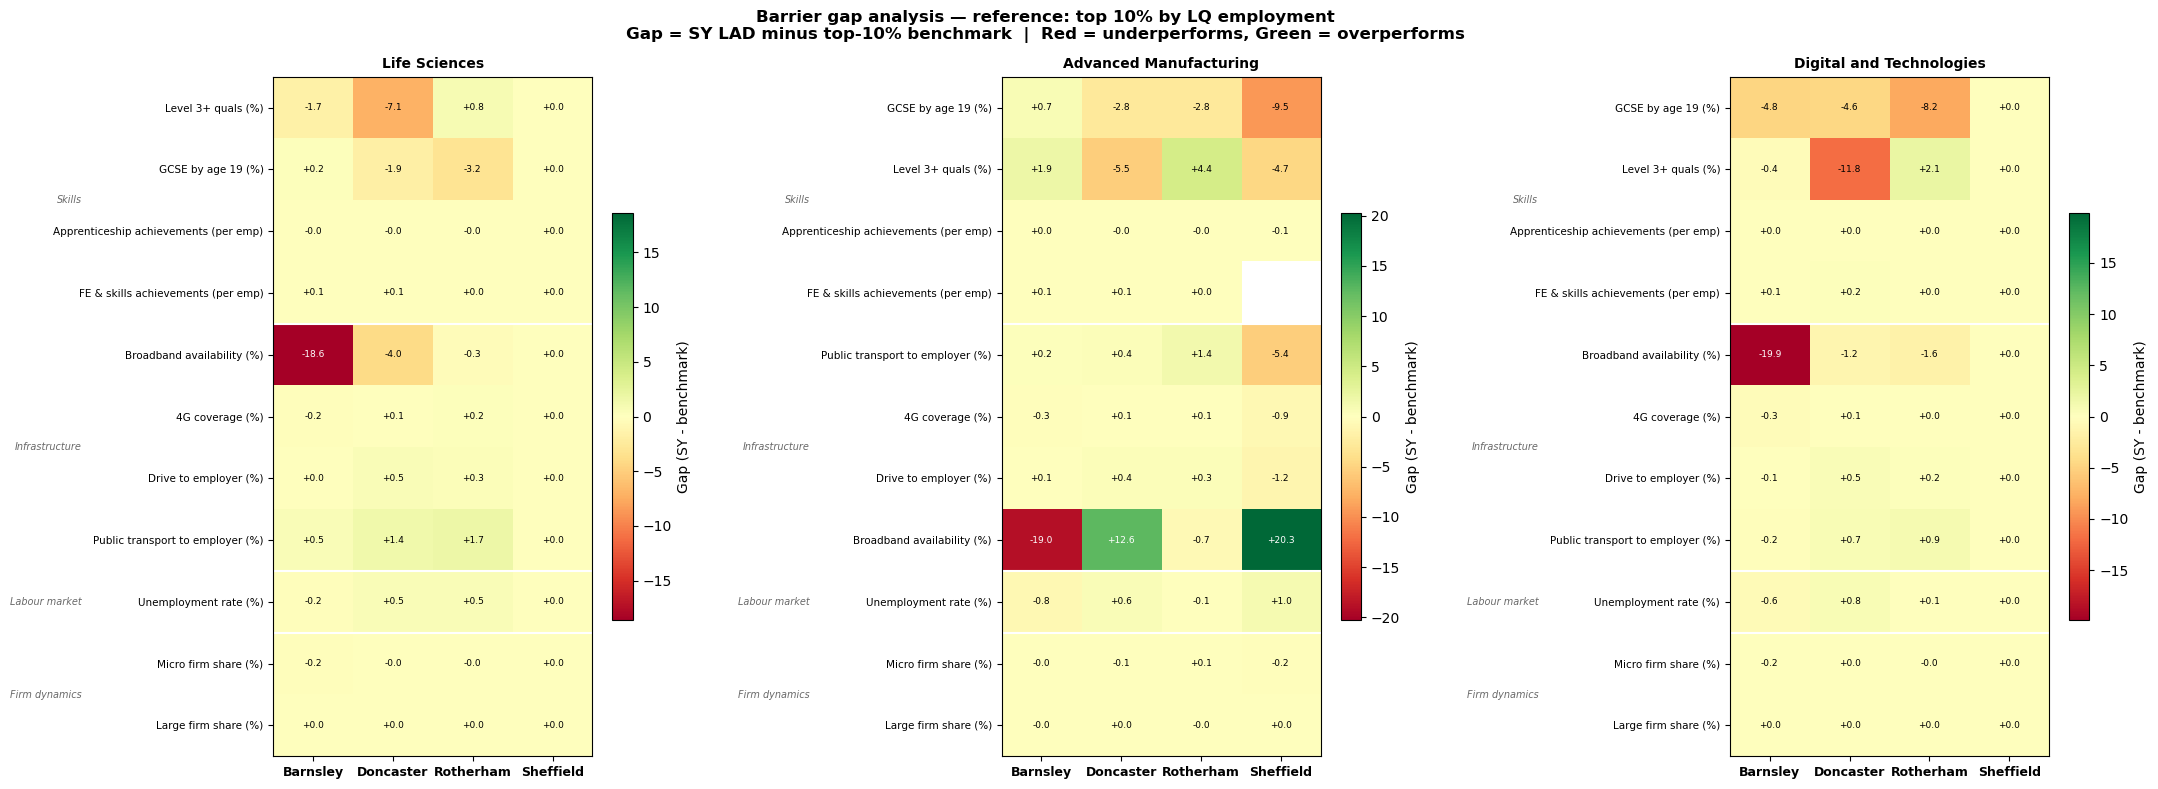

Saved: ../../output/graphs/franco/barrier_gap_lq_emp.png


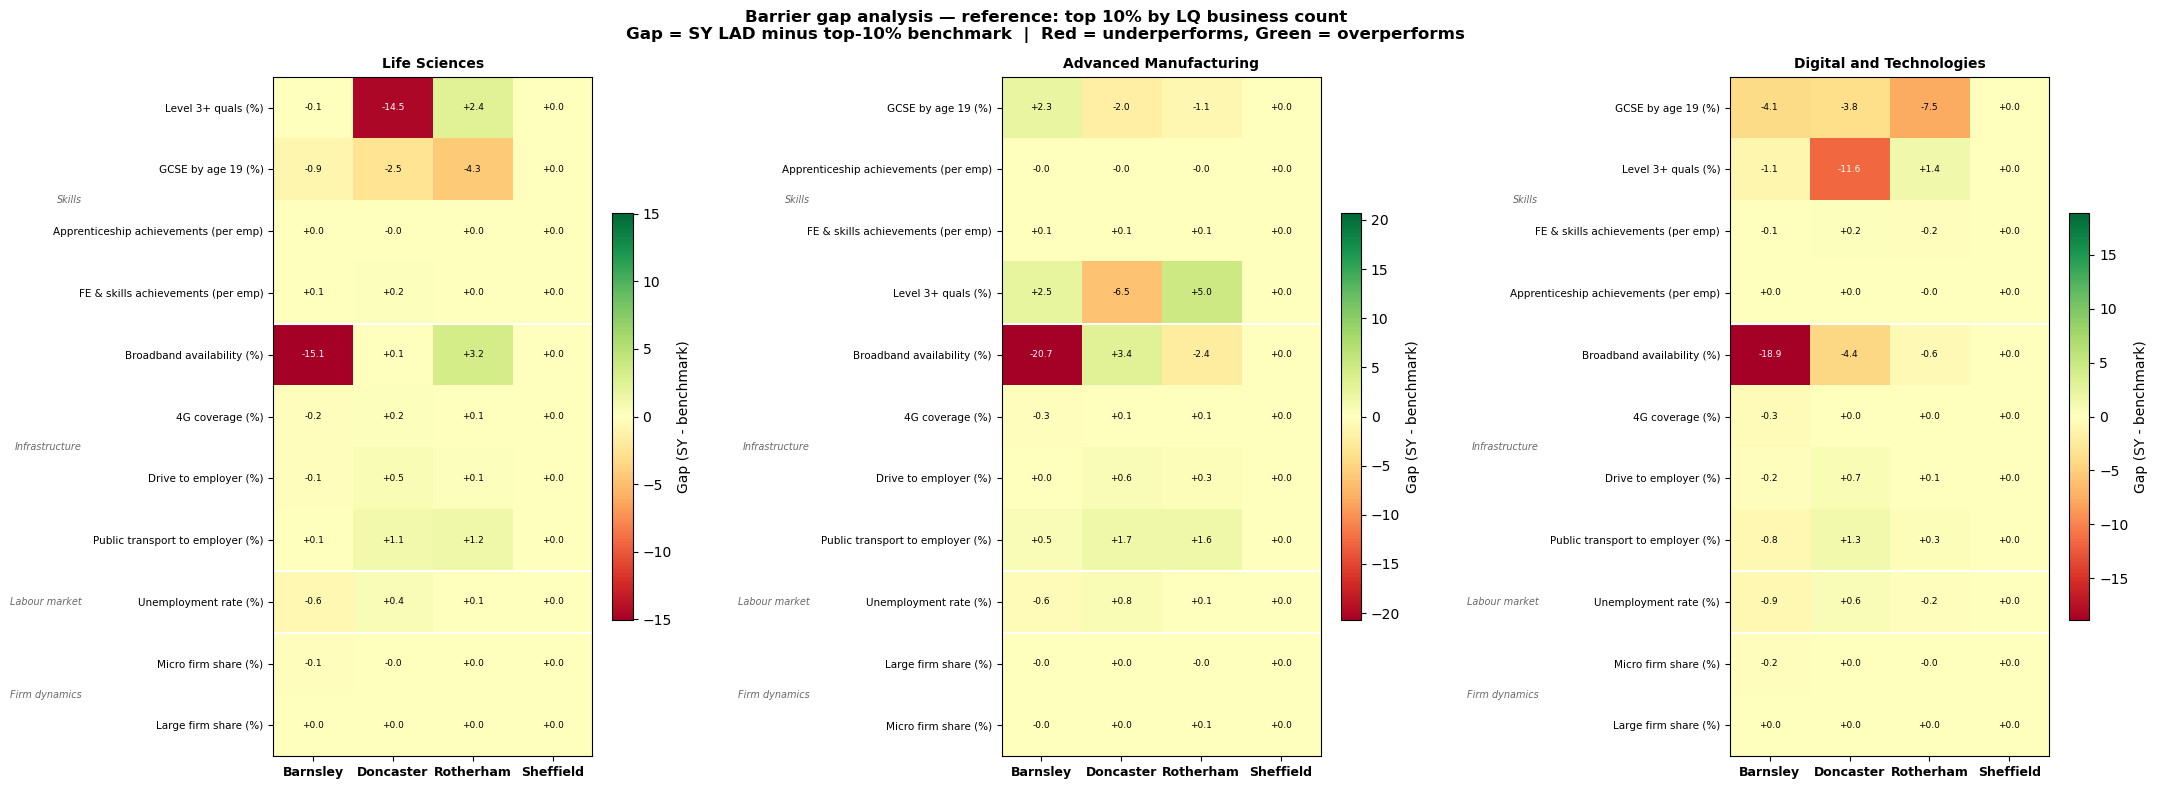

Saved: ../../output/graphs/franco/barrier_gap_lq_bus.png


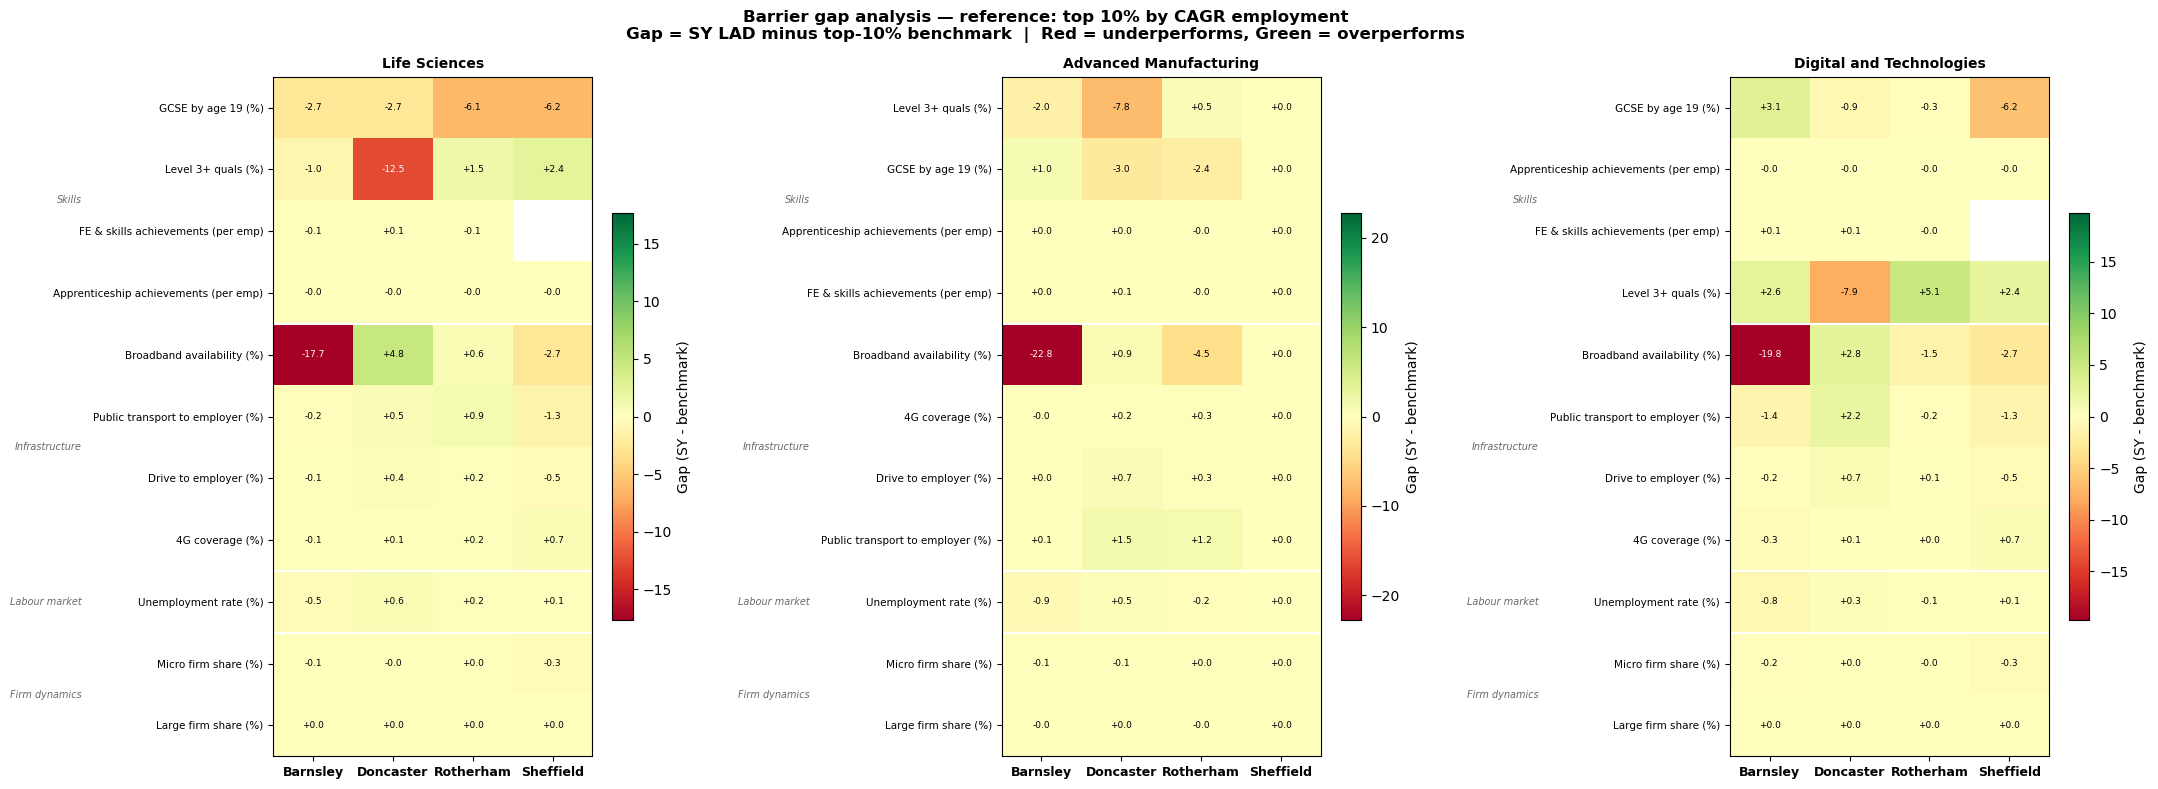

Saved: ../../output/graphs/franco/barrier_gap_cagr_emp.png


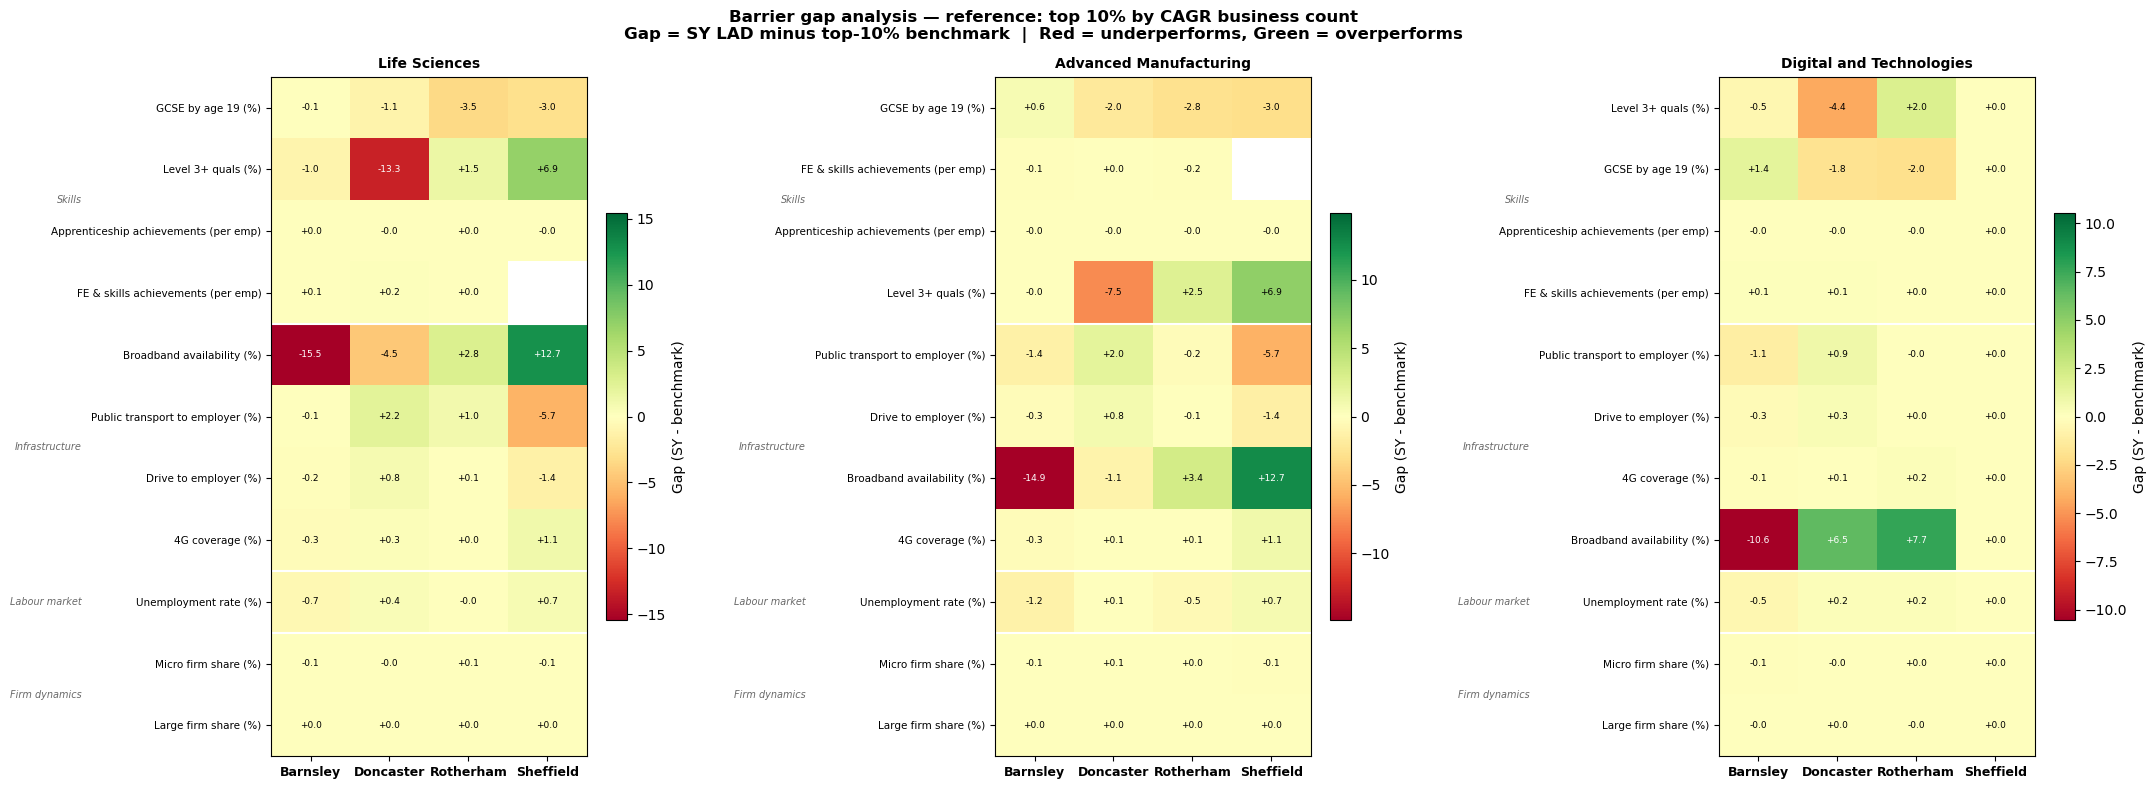

Saved: ../../output/graphs/franco/barrier_gap_cagr_bus.png


In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import os

OUTPUT_DIR = "../../output/graphs/franco"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
# CELL 6 — Barrier analysis
#
# For each focus sector × reference metric combination:
#   1. Within each SY LAD's cluster, identify the top 5% of
#      LADs by that metric — these are the "achievable" peers
#   2. Compute the mean of those top performers on each
#      barrier variable — this is the reference benchmark
#   3. Compute the gap: SY LAD value minus benchmark
#      Negative gap = SY underperforms → potential barrier
#      Positive gap = SY overperforms → not a constraint
#
# Output: one heatmap per reference metric (4 total)
#   Rows = barrier variables
#   Columns = 4 SY LADs
#   Colour = gap magnitude (red = underperform, green = over)
#   Faceted by focus sector (3 panels per heatmap)
# ============================================================

BARRIER_VARS = {
    # Skills
    "level_3+_qualifications":     "Level 3+ quals (%)",
    "gcse_by_age_19":               "GCSE by age 19 (%)",
    "apprenticeship_achievements":  "Apprenticeship achievements (per emp)",
    "fe_and_skills_achievements":   "FE & skills achievements (per emp)",
    # Infrastructure
    "broadband_availability":       "Broadband availability (%)",
    "4g_area_coverage":             "4G coverage (%)",
    "drive_to_employer":            "Drive to employer (%)",
    "public_transport_to_employer": "Public transport to employer (%)",
    # Labour market
    "unemployment_rate":            "Unemployment rate (%)",
    # Firm dynamics
    "size_large_share":             "Large firm share (%)",
    "size_micro_share":             "Micro firm share (%)",
}

BARRIER_GROUPS = {
    "Skills":         ["level_3+_qualifications", "gcse_by_age_19",
                       "apprenticeship_achievements", "fe_and_skills_achievements"],
    "Infrastructure": ["broadband_availability", "4g_area_coverage",
                       "drive_to_employer", "public_transport_to_employer"],
    "Labour market":  ["unemployment_rate"],
    "Firm dynamics":  ["size_large_share", "size_micro_share"],
}

REFERENCE_METRICS = [
    ("lq_emp",   "LQ employment"),
    ("lq_bus",   "LQ business count"),
    ("cagr_emp", "CAGR employment"),
    ("cagr_bus", "CAGR business count"),
]

SY_LAD_NAMES = {
    "E08000016": "Barnsley",
    "E08000017": "Doncaster",
    "E08000018": "Rotherham",
    "E08000019": "Sheffield",
}

SY_CLUSTER_MAP = {
    "E08000016": 6,
    "E08000017": 7,
    "E08000018": 6,
    "E08000019": 9,
}

# Get barrier variable values — LAD level, 2022, deduplicated
barrier_df = (
    panel[panel["YEAR"] == YEAR]
    .drop_duplicates(subset="GEOGRAPHY_CODE")
    .set_index("GEOGRAPHY_CODE")
    [list(BARRIER_VARS.keys())]
    .copy()
)

# ── Local normalisation of count variables ───────────────────
# These are raw counts that vary with LAD size — dividing by
# total employment converts them to rates per employee, making
# cross-LAD comparison valid. Proper fix belongs in the pipeline.
COUNT_VARS = [
    "fe_and_skills_achievements",
    "apprenticeship_achievements",
    "apprenticeship_starts",
    "fe_and_skills_participation",
]
total_emp = (
    panel[panel["YEAR"] == YEAR]
    .groupby("GEOGRAPHY_CODE")["EMPLOYEES"]
    .sum()
)
for var in COUNT_VARS:
    if var in barrier_df.columns:
        barrier_df[var] = barrier_df[var] / total_emp.reindex(barrier_df.index)

print("=== NORMALISED COUNT VARIABLES (per employee) ===")
print(barrier_df[[v for v in COUNT_VARS if v in barrier_df.columns]].describe().round(4))

# Get IS8 metric values per LAD × sector
metric_df = (
    panel[panel["YEAR"] == YEAR]
    .set_index(["GEOGRAPHY_CODE", "IS8_SECTOR"])
    [["lq_emp", "lq_bus", "cagr_emp", "cagr_bus"]]
    .copy()
)

for ref_metric, ref_label in REFERENCE_METRICS:

    fig, axes = plt.subplots(1, 3, figsize=(22, 8))
    fig.suptitle(
        f"Barrier gap analysis — reference: top 10% by {ref_label}\n"
        "Gap = SY LAD minus top-10% benchmark  |  Red = underperforms, Green = overperforms",
        fontsize=12, fontweight="bold"
    )

    for ax, sector in zip(axes, FOCUS_SECTORS):

        gap_records = []

        for sy_code, sy_name in SY_LAD_NAMES.items():
            cid = SY_CLUSTER_MAP[sy_code]
            cluster_codes = lad_df[lad_df["cluster"] == cid].index.tolist()

            # Get metric values for all LADs in cluster for this sector
            try:
                sec_metrics = (
                    metric_df.xs(sector, level="IS8_SECTOR")[ref_metric]
                    .reindex(cluster_codes)
                    .dropna()
                )
            except KeyError:
                continue

            if len(sec_metrics) == 0:
                continue

            # Top 5% threshold — at least 1 LAD
            n_top = max(1, int(np.ceil(len(sec_metrics) * 0.10)))
            top_codes = sec_metrics.nlargest(n_top).index.tolist()

            # Mean of top 5% on each barrier variable
            top_barrier = barrier_df.reindex(top_codes).mean()

            # SY LAD barrier values
            sy_barrier = barrier_df.loc[sy_code] if sy_code in barrier_df.index else pd.Series(dtype=float)

            # Gap = SY - benchmark
            gap = sy_barrier - top_barrier

            for var in BARRIER_VARS:
                if var in gap.index and pd.notna(gap[var]):
                    gap_records.append({
                        "lad":      sy_name,
                        "variable": var,
                        "gap":      float(gap[var]),
                        "sy_val":   float(sy_barrier.get(var, np.nan)),
                        "ref_val":  float(top_barrier.get(var, np.nan)),
                    })

        if not gap_records:
            ax.set_title(f"{sector}\n(no data)", fontsize=9)
            continue

        gap_df = pd.DataFrame(gap_records)
        pivot   = gap_df.pivot(index="variable", columns="lad", values="gap")

        # Order rows by group, then by mean gap (most negative first)
        ordered_vars = []
        group_boundaries = []
        for grp, vars_in_grp in BARRIER_GROUPS.items():
            valid = [v for v in vars_in_grp if v in pivot.index]
            if valid:
                valid_sorted = sorted(valid, key=lambda v: pivot.loc[v].mean())
                ordered_vars.extend(valid_sorted)
                group_boundaries.append((len(ordered_vars), grp))

        pivot = pivot.reindex(ordered_vars)
        pivot.index = [BARRIER_VARS[v] for v in ordered_vars]

        # Symmetric colour scale
        abs_max = pivot.abs().max().max()
        if abs_max == 0:
            abs_max = 1

        im = ax.imshow(
            pivot.values,
            aspect="auto",
            cmap="RdYlGn",
            vmin=-abs_max,
            vmax=abs_max,
        )

        # Axes labels
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns, fontsize=9, fontweight="bold")
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index, fontsize=7.5)
        ax.set_title(sector, fontsize=10, fontweight="bold")

        # Cell values
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                val = pivot.values[i, j]
                if not np.isnan(val):
                    ax.text(j, i, f"{val:+.1f}",
                            ha="center", va="center",
                            fontsize=6.5,
                            color="black" if abs(val) < abs_max * 0.6 else "white")

        # Group separator lines
        cum = 0
        for boundary, grp_name in group_boundaries[:-1]:
            ax.axhline(boundary - 0.5, color="white", linewidth=1.5)

        # Group labels on left
        cum = 0
        for i, (boundary, grp_name) in enumerate(group_boundaries):
            mid = (cum + boundary - 1) / 2
            ax.text(-0.6, mid, grp_name,
                    ha="right", va="center",
                    fontsize=7, color="dimgrey",
                    fontstyle="italic",
                    transform=ax.get_yaxis_transform())
            cum = boundary

        plt.colorbar(im, ax=ax, shrink=0.6, label="Gap (SY - benchmark)")

    plt.tight_layout()
    fname = f"{OUTPUT_DIR}/barrier_gap_{ref_metric}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

In [24]:
# ============================================================
# CELL 6b — Summary table: consistent barriers across metrics
#
# A variable flagged as negative (barrier) across all 4 metrics
# is a robust finding. This table counts how many times each
# variable × LAD × sector combination is in the red.
# ============================================================

print("\n=== ROBUST BARRIERS (negative gap in 3+ of 4 metrics) ===")
print("These variables consistently underperform against top performers\n")

all_gaps = []
for ref_metric, ref_label in REFERENCE_METRICS:
    for sector in FOCUS_SECTORS:
        for sy_code, sy_name in SY_LAD_NAMES.items():
            cid = SY_CLUSTER_MAP[sy_code]
            cluster_codes = lad_df[lad_df["cluster"] == cid].index.tolist()
            try:
                sec_metrics = (
                    metric_df.xs(sector, level="IS8_SECTOR")[ref_metric]
                    .reindex(cluster_codes).dropna()
                )
            except KeyError:
                continue
            if len(sec_metrics) == 0:
                continue
            n_top = max(1, int(np.ceil(len(sec_metrics) * 0.10)))
            top_codes = sec_metrics.nlargest(n_top).index.tolist()
            top_barrier = barrier_df.reindex(top_codes).mean()
            sy_barrier  = barrier_df.loc[sy_code] if sy_code in barrier_df.index else pd.Series(dtype=float)
            gap = sy_barrier - top_barrier
            for var in BARRIER_VARS:
                if var in gap.index and pd.notna(gap[var]):
                    all_gaps.append({
                        "metric": ref_metric, "sector": sector,
                        "lad": sy_name, "variable": var,
                        "gap": float(gap[var]), "negative": float(gap[var]) < 0
                    })

gaps_df = pd.DataFrame(all_gaps)
robust = (
    gaps_df.groupby(["sector", "lad", "variable"])["negative"]
    .sum()
    .reset_index()
    .rename(columns={"negative": "n_negative"})
)
robust = robust[robust["n_negative"] >= 3].sort_values(
    ["sector", "lad", "n_negative"], ascending=[True, True, False]
)
print(robust.to_string(index=False))


=== ROBUST BARRIERS (negative gap in 3+ of 4 metrics) ===
These variables consistently underperform against top performers

                  sector       lad                     variable  n_negative
  Advanced Manufacturing  Barnsley             4g_area_coverage           4
  Advanced Manufacturing  Barnsley       broadband_availability           4
  Advanced Manufacturing  Barnsley             size_micro_share           4
  Advanced Manufacturing  Barnsley            unemployment_rate           4
  Advanced Manufacturing  Barnsley             size_large_share           3
  Advanced Manufacturing Doncaster               gcse_by_age_19           4
  Advanced Manufacturing Doncaster      level_3+_qualifications           4
  Advanced Manufacturing Doncaster  apprenticeship_achievements           3
  Advanced Manufacturing Rotherham  apprenticeship_achievements           4
  Advanced Manufacturing Rotherham               gcse_by_age_19           4
  Advanced Manufacturing Rotherham     

**Barnsley — the most constrained LAD across all three sectors**

Five variables appear as robust barriers (n=4) across all sectors: `broadband_availability`, `4g_area_coverage`, `size_micro_share`, `unemployment_rate`, and `level_3+_qualifications` (on Life Sciences and Digital). Transport accessibility (`drive_to_employer`, `public_transport_to_employer`) also appears on Digital. This is a compound barrier profile — infrastructure, labour market, skills, and firm structure all constrain simultaneously. No single intervention fixes Barnsley.

**Doncaster — skills pipeline is the binding constraint**

`gcse_by_age_19` and `level_3+_qualifications` appear as n=4 across all three sectors. `apprenticeship_achievements` appears on Life Sciences and Advanced Manufacturing. `size_micro_share` appears on Life Sciences. The pattern is consistent — Doncaster's workforce qualification level is the primary gap relative to top performers in its cluster. Infrastructure is not an issue.

**Rotherham — moderate, skills-focused**

`gcse_by_age_19` is the most consistent barrier (n=4 on Advanced Manufacturing, Digital, Life Sciences). `apprenticeship_achievements` appears on Advanced Manufacturing and Digital. Broadband appears on Advanced Manufacturing and Digital but not Life Sciences. Rotherham is closer to its top performers than Barnsley or Doncaster — the gaps are smaller and less numerous.

**Sheffield — no barriers identified**

Method limitation as discussed.

---

**The synthesis across all three sectors and four LADs:**

| Variable | Barnsley | Doncaster | Rotherham | Type |
|---|---|---|---|---|
| Broadband availability | ✗✗✗ | — | partial | Infrastructure |
| 4G coverage | ✗✗✗ | — | — | Infrastructure |
| Transport accessibility | ✗✗ | — | — | Infrastructure |
| Unemployment rate | ✗✗✗ | — | partial | Labour market |
| Level 3+ qualifications | ✗✗✗ | ✗✗✗ | — | Skills |
| GCSE by age 19 | partial | ✗✗✗ | ✗✗✗ | Skills |
| Apprenticeship achievements | — | partial | partial | Skills |
| Size micro share | ✗✗✗ | partial | partial | Firm dynamics |

---

**The policy implication for the write-up:**

There are two distinct intervention logics depending on which LAD you're talking about:

For **Doncaster and Rotherham** the binding constraint is skills — specifically qualification attainment at GCSE and Level 3. These are solvable through FE investment and employer-led training programmes. The industrial base and infrastructure are adequate.

For **Barnsley** the barriers are structural and compound. Broadband and connectivity gaps mean IS8 firms won't locate there regardless of skills supply. The high micro-firm share and low large-firm share means there's no anchor employer to drive demand for higher skills. This requires infrastructure investment as a prerequisite, followed by firm attraction, before skills interventions become effective.

LADs with complete IS8 data (excl. Defence): 350


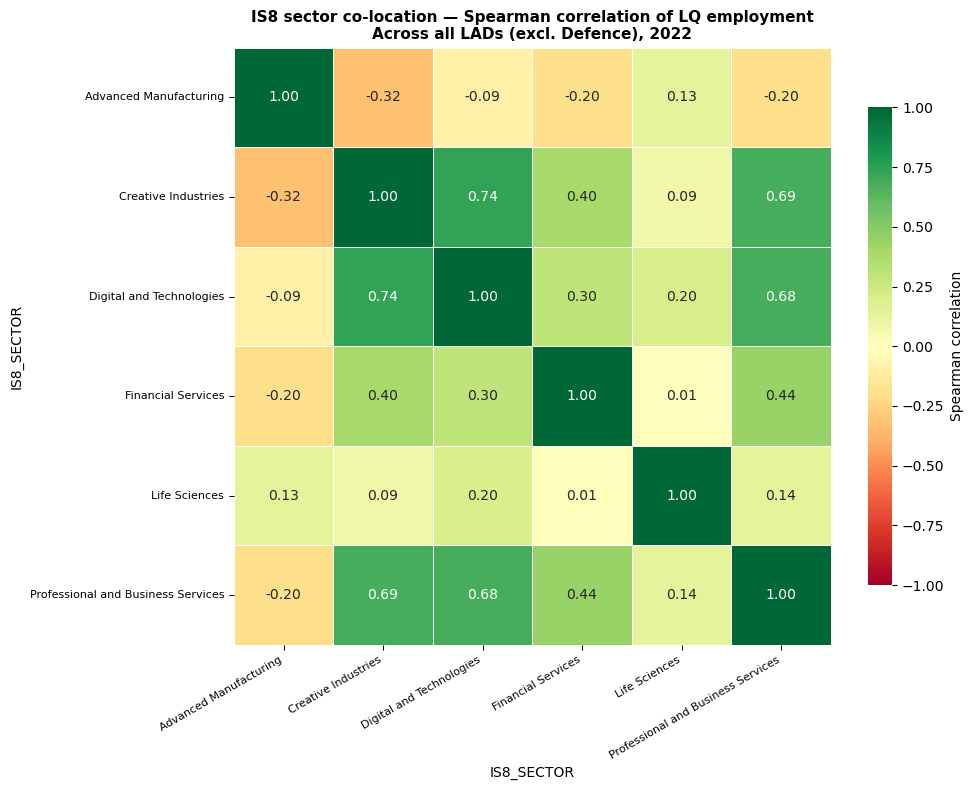

Saved: ../../output/graphs/franco/adjacency_correlation_matrix.png

=== CORRELATION RANKING FOR FOCUS SECTORS ===

Life Sciences — most correlated IS8 sectors:
  Digital and Technologies                      r=+0.196
  Professional and Business Services            r=+0.138
  Advanced Manufacturing                        r=+0.135
  Creative Industries                           r=+0.093
  Financial Services                            r=+0.012

Advanced Manufacturing — most correlated IS8 sectors:
  Life Sciences                                 r=+0.135
  Digital and Technologies                      r=-0.092
  Professional and Business Services            r=-0.196
  Financial Services                            r=-0.200
  Creative Industries                           r=-0.324

Digital and Technologies — most correlated IS8 sectors:
  Creative Industries                           r=+0.740
  Professional and Business Services            r=+0.683
  Financial Services                        

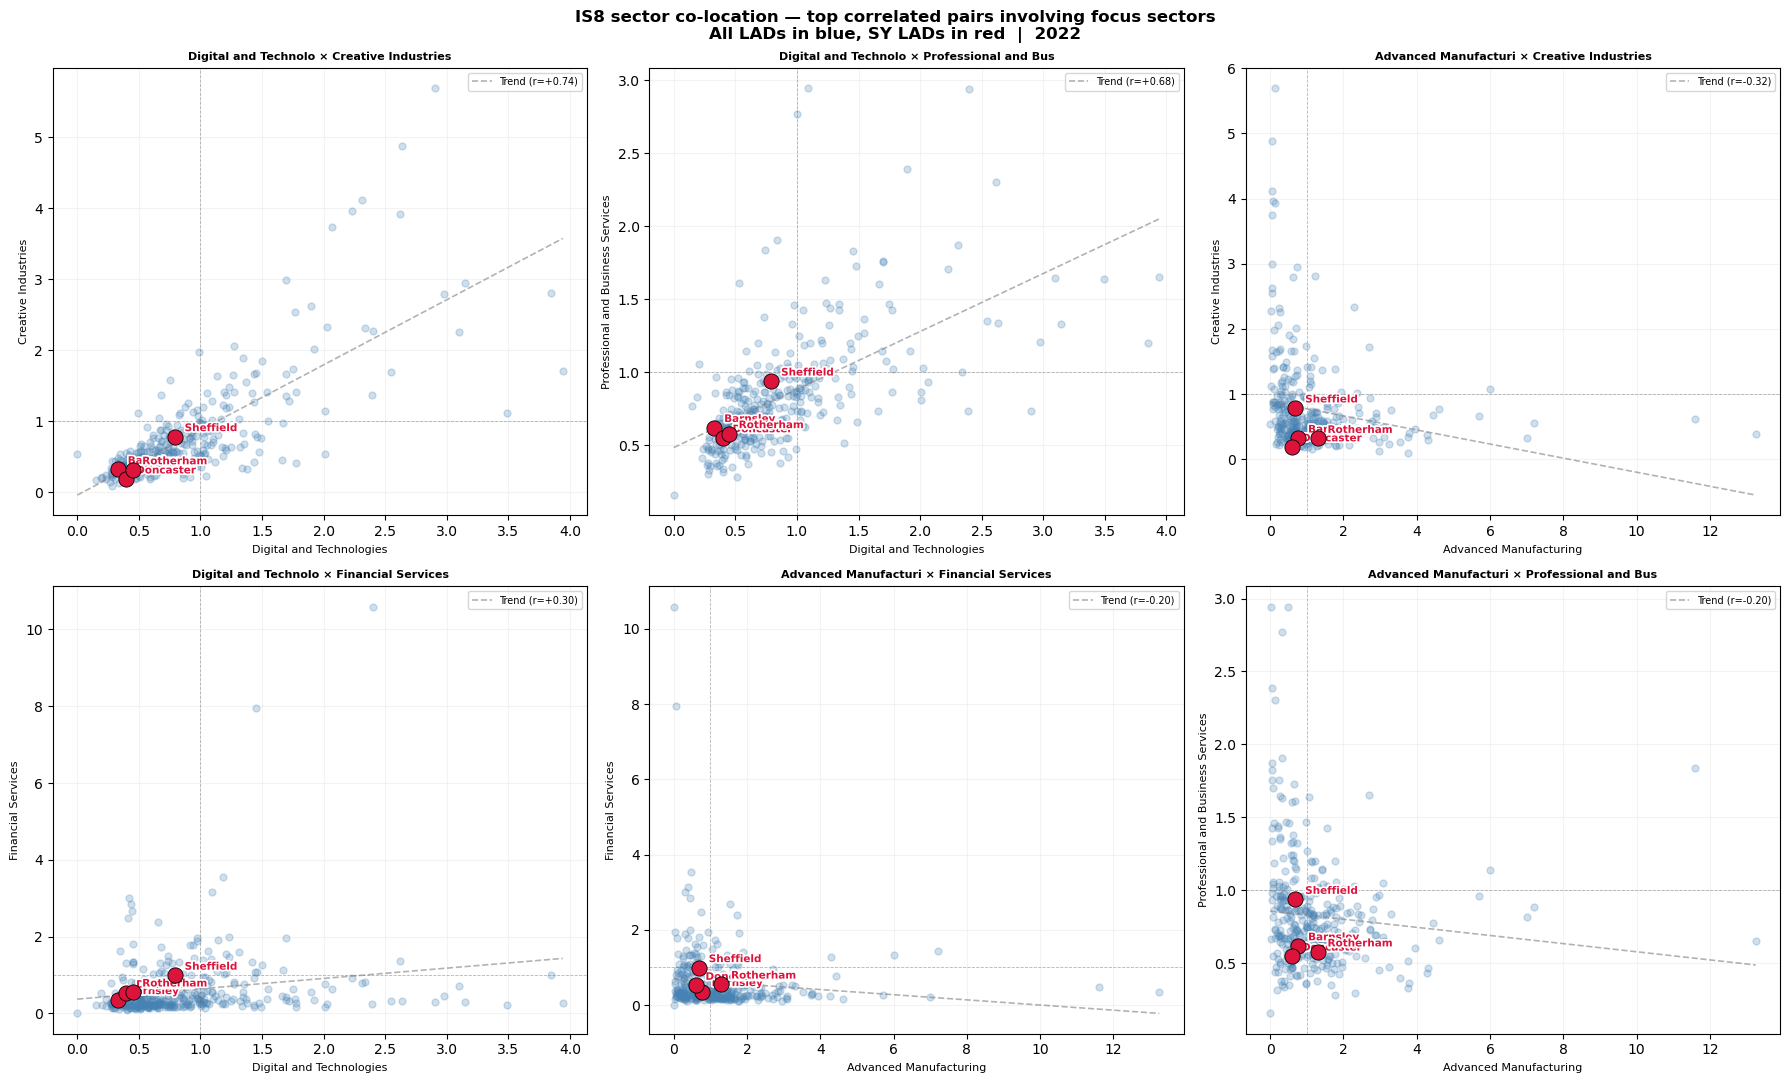

Saved: ../../output/graphs/franco/adjacency_scatter_pairs.png

=== SY ADJACENCY PROFILE ===
For each focus sector, SY's LQ on correlated IS8 sectors

--- Life Sciences ---
  Digital and Technologies                      r=+0.196  SY LQ=0.49  ▼ below avg
  Professional and Business Services            r=+0.138  SY LQ=0.67  ▼ below avg
  Advanced Manufacturing                        r=+0.135  SY LQ=0.84  ▼ below avg
  Creative Industries                           r=+0.093  SY LQ=0.41  ▼ below avg
  Financial Services                            r=+0.012  SY LQ=0.61  ▼ below avg

--- Advanced Manufacturing ---
  Life Sciences                                 r=+0.135  SY LQ=0.72  ▼ below avg
  Digital and Technologies                      r=-0.092  SY LQ=0.49  ▼ below avg
  Professional and Business Services            r=-0.196  SY LQ=0.67  ▼ below avg
  Financial Services                            r=-0.200  SY LQ=0.61  ▼ below avg
  Creative Industries                           r=-0.324  

In [25]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
import pandas as pd
import seaborn as sns
import os

OUTPUT_DIR = "../../output/graphs/franco"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
# CELL 7 — Cross-sector co-location adjacency analysis
#
# Step 1: Correlation matrix of IS8 sector LQs across all LADs
#   If two sectors tend to co-locate (high LQ together), they
#   are likely drawing on similar local conditions — adjacency.
#   High positive correlation = natural adjacency
#   Near-zero correlation = independent location drivers
#   Negative correlation = competing for the same resources
#
# Step 2: Scatter plots for the most relevant sector pairs
#   Show where SY LADs sit on each correlated pair — are they
#   exploiting or missing the adjacency?
#
# Step 3: SY-specific adjacency profile
#   For each focus sector, rank all other IS8 sectors by their
#   correlation with it, then show SY's LQ on each — which
#   adjacencies does SY have that it could leverage?
# ============================================================

SECTORS = [s for s in panel["IS8_SECTOR"].unique() if s != "Defence"]

# ── Step 1: Build wide LQ matrix (LAD × sector) ─────────────
lq_wide = (
    panel[panel["YEAR"] == YEAR]
    .pivot_table(index="GEOGRAPHY_CODE", columns="IS8_SECTOR", values="lq_emp")
    .drop(columns=["Defence"], errors="ignore")
    .dropna()
)

print(f"LADs with complete IS8 data (excl. Defence): {len(lq_wide)}")

# Correlation matrix
corr = lq_wide.corr(method="spearman")  # Spearman — robust to outlier LQs

# ── Plot 1: Correlation heatmap ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # upper triangle only

sns.heatmap(
    corr,
    ax=ax,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8, "label": "Spearman correlation"},
)
ax.set_title(
    "IS8 sector co-location — Spearman correlation of LQ employment\n"
    "Across all LADs (excl. Defence), 2022",
    fontsize=11, fontweight="bold"
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
fname = f"{OUTPUT_DIR}/adjacency_correlation_matrix.png"
plt.savefig(fname, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fname}")

# Print correlation ranking for focus sectors
print("\n=== CORRELATION RANKING FOR FOCUS SECTORS ===")
for sector in FOCUS_SECTORS:
    print(f"\n{sector} — most correlated IS8 sectors:")
    ranked = corr[sector].drop(sector).sort_values(ascending=False)
    for s, r in ranked.items():
        print(f"  {s:<45} r={r:+.3f}")

# ── Step 2: Scatter plots for relevant pairs ─────────────────
# Identify top correlated pairs involving focus sectors
pairs = []
for s1 in FOCUS_SECTORS:
    for s2 in SECTORS:
        if s2 == s1:
            continue
        r = corr.loc[s1, s2]
        pairs.append((abs(r), r, s1, s2))

pairs = sorted(pairs, reverse=True)
# Take top 6 unique pairs (avoid duplicates)
seen, top_pairs = set(), []
for _, r, s1, s2 in pairs:
    key = tuple(sorted([s1, s2]))
    if key not in seen:
        seen.add(key)
        top_pairs.append((r, s1, s2))
    if len(top_pairs) == 6:
        break

# SY MCA aggregated LQs (mean across 4 LADs)
sy_lq_wide = lq_wide.reindex(SY_CODES).mean()

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    "IS8 sector co-location — top correlated pairs involving focus sectors\n"
    "All LADs in blue, SY LADs in red  |  2022",
    fontsize=12, fontweight="bold"
)

for ax, (r, s1, s2) in zip(axes.flatten(), top_pairs):
    x_all = lq_wide[s1].values
    y_all = lq_wide[s2].values
    codes = lq_wide.index.tolist()
    names = (
        panel[panel["YEAR"] == YEAR]
        .drop_duplicates("GEOGRAPHY_CODE")
        .set_index("GEOGRAPHY_CODE")["GEOGRAPHY_NAME"]
        .reindex(codes)
        .values
    )
    is_sy = np.array([c in SY_CODES for c in codes])

    # All LADs
    ax.scatter(x_all[~is_sy], y_all[~is_sy],
               color="steelblue", alpha=0.25, s=25, zorder=2)

    # Trend line
    z = np.polyfit(x_all, y_all, 1)
    p = np.poly1d(z)
    xl = np.linspace(x_all.min(), x_all.max(), 200)
    ax.plot(xl, p(xl), "--", color="grey", linewidth=1.2,
            alpha=0.6, zorder=3, label=f"Trend (r={r:+.2f})")

    # SY LADs
    for xi, yi, nm, sy in zip(x_all, y_all, names, is_sy):
        if not sy:
            continue
        ax.scatter(xi, yi, color="crimson", s=120, zorder=6,
                   edgecolors="black", linewidths=0.6)
        ax.annotate(nm, (xi, yi),
                    xytext=(7, 4), textcoords="offset points",
                    fontsize=7.5, color="crimson", fontweight="bold",
                    path_effects=[pe.withStroke(linewidth=2.5,
                                                foreground="white")])

    ax.axvline(1.0, color="dimgrey", linewidth=0.6,
               linestyle="--", alpha=0.5)
    ax.axhline(1.0, color="dimgrey", linewidth=0.6,
               linestyle="--", alpha=0.5)
    ax.set_xlabel(s1, fontsize=8)
    ax.set_ylabel(s2, fontsize=8)
    ax.set_title(f"{s1[:20]} × {s2[:20]}", fontsize=8, fontweight="bold")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.15)

plt.tight_layout()
fname = f"{OUTPUT_DIR}/adjacency_scatter_pairs.png"
plt.savefig(fname, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fname}")

# ── Step 3: SY adjacency profile ─────────────────────────────
# For each focus sector, show SY's LQ on correlated sectors
print("\n=== SY ADJACENCY PROFILE ===")
print("For each focus sector, SY's LQ on correlated IS8 sectors\n")

for sector in FOCUS_SECTORS:
    print(f"--- {sector} ---")
    ranked = corr[sector].drop(sector).sort_values(ascending=False)
    for s, r in ranked.items():
        sy_lq = sy_lq_wide.get(s, np.nan)
        above = "▲ above avg" if sy_lq > 1.0 else "▼ below avg"
        print(f"  {s:<45} r={r:+.3f}  SY LQ={sy_lq:.2f}  {above}")
    print()

**The correlation matrix — the big structural insight**

Advanced Manufacturing is **negatively correlated** with almost everything: Creative Industries (-0.32), Financial Services (-0.20), Professional & Business Services (-0.20). It's essentially orthogonal to the urban knowledge economy cluster. The only positive correlation is with Life Sciences (+0.13) — weak but notable.

Digital, Creative, Professional & Business Services and Financial Services form a tight urban cluster — correlations of 0.68–0.74 between them. These sectors co-locate in the same types of places: city centres, graduate economies, dense service sectors.

Life Sciences is the most independent sector — weak positive correlations with everything, no strong co-location pattern. It follows its own logic (proximity to research hospitals, universities, specific supply chains).

**The SY adjacency profile — the uncomfortable finding**

Every single entry is "▼ below avg". SY is below LQ=1 on every IS8 sector that correlates with its three focus sectors. This means SY doesn't currently have a strong adjacency base to leverage from within IS8 sectors.

But read it more carefully:

For **Life Sciences** the correlations are all weak (max r=+0.20) — Life Sciences doesn't strongly co-locate with anything. So the absence of adjacent IS8 sectors in SY doesn't really constrain Life Sciences development. Sheffield's anchor is driven by non-IS8 factors (university, NHS) not by IS8 adjacency.

For **Advanced Manufacturing** the correlations are all negative or near-zero. Advanced Manufacturing actively doesn't co-locate with the urban knowledge economy. SY's below-average scores on Creative, Financial, and Professional Services are therefore not barriers — they're irrelevant or even structurally expected for a manufacturing economy.

For **Digital & Technologies** the strong correlation with Creative Industries (r=+0.74) and Professional & Business Services (r=+0.68) is the critical finding. SY scores below average on both. This is the adjacency gap — Digital tends to grow where Creative and Professional services are already present, and SY is weak on both.

---

**The revised adjacency argument:**

| Focus sector | Key adjacency | SY position | Implication |
|---|---|---|---|
| Life Sciences | Weakly correlated with everything — location-independent | All adjacent sectors below avg — but doesn't matter | Sheffield's anchor is institutional not adjacency-driven |
| Advanced Manufacturing | Negatively correlated with urban knowledge economy — stands alone | Expected — manufacturing doesn't need creative/financial sectors nearby | Humber Clean Energy adjacency is the real argument, not IS8 cross-sector |
| Digital & Technologies | Strongly tied to Creative Industries (0.74) and Prof Services (0.68) | Both below avg in SY — genuine adjacency gap | Creative sector weakness is a binding constraint on Digital growth |

The most actionable finding is the Digital-Creative link. SY's Creative Industries LQ of 0.74 (employment) is directly implicated in the Digital underperformance. Investing in creative sector presence — particularly in Sheffield where it's least weak — could unlock Digital growth through the adjacency mechanism.

## Narrative Structure

### 1. Opening framing (1 paragraph)
South Yorkshire MCA is not one economy — the dendrogram showed this before we wrote a single sentence. Sheffield clusters separately from Barnsley, Doncaster and Rotherham. Everything that follows is structured around that internal differentiation. The MCA aggregate masks more than it reveals.

---

### 2. Current IS8 footprint (1 paragraph + table from Cell 1)
Present the footprint table. Three sectors above national average: Life Sciences (1.51), Professional & Business Services (1.09), Advanced Manufacturing (1.16 employment / 1.69 business count). The business count gap in Advanced Manufacturing signals SME fragmentation — many firms, limited depth. Defence absent. Creative Industries and Digital below average.

---

### 3. Trajectory — anchor, emerging, declining (1 paragraph + quadrant plots 5c)
- Life Sciences: growing strongly (CAGR 12.6%, well above national median) — anchor at MCA level, but driven entirely by Sheffield
- Advanced Manufacturing: employment growing above national median, business counts positive — momentum sector
- Digital & Technologies: employment declining below national median for Barnsley and Rotherham, Doncaster and Sheffield slightly positive — the most mixed picture
- Use the quadrant plots to show this visually

---

### 4. Internal differentiation — the LAD-level story (2 paragraphs + scatter plots 5a/5b)
This is the analytical contribution of Phase 2 over the regional picture.

**Paragraph 1 — Life Sciences:**
Sheffield (LQ 1.90) overperforms relative to its structural peer group — above the cluster trend line, converting related variety into sector presence. Barnsley, Doncaster and Rotherham sit at the bottom of their cluster despite similar related variety values. Peer comparators Broxtowe (LQ 7.66) and Halton (LQ 5.78) show what is achievable with similar structural conditions. The barrier is institutional — Sheffield has the University of Sheffield, Sheffield Hallam, and two major NHS trusts; the other three have none of these anchors.

**Paragraph 2 — Advanced Manufacturing and Digital:**
Advanced Manufacturing is performing broadly as structural position predicts — Rotherham slightly above trend, others on it. The SME fragmentation story is visible in the business count plots — firm presence is proportional to related variety but employment depth lags. Digital is the most analytically distinctive case: all four LADs sit at the high end of related variety nationally but none are converting it into employment or firm presence. The co-location analysis reveals why — Digital growth nationally is strongly tied to Creative Industries (r=+0.74) and Professional & Business Services (r=+0.68), and SY is below average on both.

---

### 5. Barriers — why is potential unrealised? (1-2 paragraphs + barrier heatmaps)
Draw directly from the robust barriers table. Two distinct intervention logics:

**Doncaster and Rotherham — skills pipeline:**
GCSE attainment and Level 3+ qualifications are robust barriers (n=4) across all three focus sectors. Apprenticeship achievements also appear consistently. The workforce qualification pipeline is the primary constraint. Infrastructure is adequate. These are addressable through FE investment and employer-led training, without requiring major capital expenditure.

**Barnsley — compound structural disadvantage:**
Broadband availability (-18 to -23pp gap), 4G coverage, transport accessibility, unemployment rate, and micro-firm dominance all appear simultaneously. This is a different order of problem. Infrastructure investment is a prerequisite before skills or firm attraction interventions can work — IS8 firms require connectivity as a basic condition of operation. The absence of large anchor employers creates a low-skill equilibrium trap: firms don't locate because skills are weak, skills don't develop because firms aren't there to demand them.

---

### 6. Adjacency — forward-looking positioning (1 paragraph)
Advanced Manufacturing does not co-locate with the urban knowledge economy — it is structurally independent. The adjacency argument for Advanced Manufacturing therefore lies outside IS8: the proximity to the Humber estuary, home to the UK's largest offshore wind installation base, creates a supply chain opportunity in Clean Energy. SY's existing Advanced Manufacturing capability in precision engineering and materials is directly applicable to wind turbine components, subsea infrastructure, and grid technology.

For Digital, the co-location analysis points to Creative Industries as the enabling adjacency. Sheffield's Creative LQ (0.85 employment, higher than the other three) makes it the most viable entry point for Digital cluster development within SY. Targeted support for creative-digital convergence in Sheffield — animation, digital media, software — could generate the spillover conditions that the EEG literature identifies as preconditions for broader digital sector growth.

---

### 7. Conclusion — sector prioritisation (1 short paragraph)
Three tiers of recommendation emerge from the analysis:
- **Consolidate**: Life Sciences in Sheffield — anchor is established, trajectory is strong, policy should deepen rather than seed
- **Develop**: Advanced Manufacturing across the MCA, with targeted Clean Energy adjacency via Humber — momentum is positive, SME fragmentation is the binding constraint
- **Invest to unlock**: Digital in Sheffield and Doncaster — related variety is present, Creative-Digital adjacency needs nurturing, skills gaps in Doncaster are addressable

Barnsley requires a different policy logic entirely — infrastructure investment before sector-specific interventions.

---

## Plot allocation for write-up

| Section | Plot |
|---|---|
| Footprint | Cell 1 table |
| Trajectory | 5c quadrant — lq_emp vs cagr_emp |
| Internal differentiation | 5b — related variety vs lq_emp (Life Sciences + Digital panels) |
| Fragmentation | 5a — structural vs lq_bus |
| Barriers | barrier_gap_lq_emp heatmap (one representative heatmap) + robust barriers table |
| Adjacency | adjacency_correlation_matrix + Digital×Creative scatter panel |